#  Mattress Market Analysis_v01

In [12]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [68]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [70]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "./market-analysis-project-91130-9f9a036682b6.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [72]:

sql = f"""
select * from wook.stckln_amz_mattress_ms_trend 
"""

df = bqclient.query(sql).to_dataframe()

In [74]:
print(df)

       RetailerSku             category    subcategory profile      size_raw  \
0       B0DQTZMFRV  Other Frames & Beds     Adjustable       4  75 x 46 Inch   
1       B0DQTZMFRV  Other Frames & Beds     Adjustable       4  75 x 46 Inch   
2       B0DQTZMFRV  Other Frames & Beds     Adjustable       4  75 x 46 Inch   
3       B0DQTZMFRV  Other Frames & Beds     Adjustable       4  75 x 46 Inch   
4       B0DQTZMFRV  Other Frames & Beds     Adjustable       4  75 x 46 Inch   
...            ...                  ...            ...     ...           ...   
518298  B0DLGTYD9Q      Spring Mattress  Pocket Spring      10          Twin   
518299  B0DLGTYD9Q      Spring Mattress  Pocket Spring      10          Twin   
518300  B0DLGTYD9Q      Spring Mattress  Pocket Spring      10          Twin   
518301  B0DLGGCVSH      Spring Mattress  Pocket Spring      12          Twin   
518302  B0DLGGCVSH      Spring Mattress  Pocket Spring      12          Twin   

          size bsr_ctgry_label Brand_ra

In [76]:
df['RetailerSku'].nunique()

23253

In [78]:
df['Brand_raw'].nunique()

884

In [80]:
# WeekEnding이 object 타입이라면 datetime으로 변환
df['WeekEnding'] = pd.to_datetime(df['WeekEnding'], errors='coerce')

# 연도 컬럼 추가
df['year'] = df['WeekEnding'].dt.year
df['year'].isna().sum()

0

In [81]:
df['yr_half'] = df['yr_month'].apply(
    lambda ym: f"{ym.split('-')[0]}-H1" if int(ym.split('-')[1]) <= 6 else f"{ym.split('-')[0]}-H2"
)

In [84]:
df.head(5)

,RetailerSku,category,subcategory,profile,size_raw,size,bsr_ctgry_label,Brand_raw,Brand_adj,Title,...,UnitsSold,RetailPrice,yr_quarter,yr_month,yr_week,week_str,retailsales_ctgry_brand,retailsales_ctgry_brand_by_6month,year,yr_half
0,B0DQTZMFRV,Other Frames & Beds,Adjustable,4,75 x 46 Inch,OTHERS,01. Mattresses,MJKONE,MJKONE,"Mjkone Folding Bed with Memory Foam Mattress, ...",...,1,240.99,25-2,25-04,Y25 W16,Y25 W16,46567.81,38349.25,2025,25-H1
1,B0DQTZMFRV,Other Frames & Beds,Adjustable,4,75 x 46 Inch,OTHERS,01. Mattresses,MJKONE,MJKONE,"Mjkone Folding Bed with Memory Foam Mattress, ...",...,4,241.99,25-3,25-07,Y25 W27,Latest Week,46567.81,38349.25,2025,25-H2
2,B0DQTZMFRV,Other Frames & Beds,Adjustable,4,75 x 46 Inch,OTHERS,01. Mattresses,MJKONE,MJKONE,"Mjkone Folding Bed with Memory Foam Mattress, ...",...,2,239.99,25-1,25-01,Y25 W04,Y25 W04,46567.81,38349.25,2025,25-H1
3,B0DQTZMFRV,Other Frames & Beds,Adjustable,4,75 x 46 Inch,OTHERS,01. Mattresses,MJKONE,MJKONE,"Mjkone Folding Bed with Memory Foam Mattress, ...",...,12,241.32,25-2,25-06,Y25 W23,Y25 W23,46567.81,38349.25,2025,25-H1
4,B0DQTZMFRV,Other Frames & Beds,Adjustable,4,75 x 46 Inch,OTHERS,01. Mattresses,MJKONE,MJKONE,"Mjkone Folding Bed with Memory Foam Mattress, ...",...,2,239.99,24-4,24-12,Y24 W51,Y24 W51,46567.81,38349.25,2024,24-H2


### 1. 기초 데이터 분석 - Mattress 카테고리

#### - 2025년 기준

In [215]:
df1 = df.copy()
df_2025 = df1[df1['year'] == 2025].copy()

In [53]:
# Brand_raw별 매출 합계 집계
asin_sales_2025 = (
    df_2025.groupby('RetailerSku')['RetailSales']
           .sum()
           .reset_index()
           .sort_values(by='RetailSales', ascending=False)
)

# 전체 매출 합계
total_sales = asin_sales_2025['RetailSales'].sum()

# 비율(Ratio) 계산
asin_sales_2025['Ratio'] = asin_sales_2025['RetailSales'] / total_sales

# 누적 비율(Cumul) 계산
asin_sales_2025['Cumul'] = asin_sales_2025['Ratio'].cumsum()

print(asin_sales_2025)

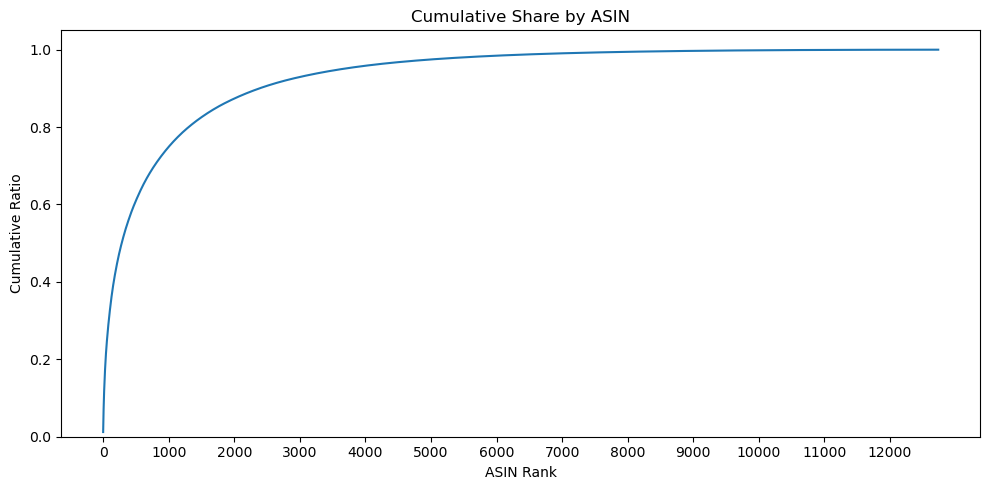

In [79]:
# x축 숫자 라벨 생성 (1부터 시작)
x_labels = list(range(0, len(asin_sales_2025)))

# 누적 점유율 그래프
plt.figure(figsize=(10, 5))
plt.plot(x_labels, asin_sales_2025['Cumul'])
plt.title("Cumulative Share by ASIN")
plt.xlabel("ASIN Rank")
plt.ylabel("Cumulative Ratio")
plt.ylim(0, 1.05)

# x축 라벨을 100 단위로 설정
step = 1000
plt.xticks(ticks=x_labels[::step], labels=x_labels[::step])

plt.tight_layout()
plt.show()

In [57]:
asin_sales_2025.to_csv('asin_sales_2025.csv', index=False)

In [63]:
# 2025년 데이터 필터링
df_2025 = df[df['year'] == 2025].copy()

# Brand_raw별 매출 합계 집계
brand_sales_2025 = (
    df_2025.groupby('Brand_raw')['RetailSales']
           .sum()
           .reset_index()
           .sort_values(by='RetailSales', ascending=False)
)

# 전체 매출 합계
total_sales = brand_sales_2025['RetailSales'].sum()

# 비율(Ratio) 계산
brand_sales_2025['Ratio'] = brand_sales_2025['RetailSales'] / total_sales

# 누적 비율(Cumul) 계산
brand_sales_2025['Cumul'] = brand_sales_2025['Ratio'].cumsum()
print(brand_sales_2025)

       Brand_raw   RetailSales         Ratio     Cumul
610        ZINUS  1.401663e+08  1.614926e-01  0.161493
386      NOVILLA  6.276125e+07  7.231037e-02  0.233803
168          FDW  3.963378e+07  4.566406e-02  0.279467
352        MLILY  3.545190e+07  4.084590e-02  0.320313
375       NECTAR  3.312092e+07  3.816027e-02  0.358473
..           ...           ...           ...       ...
547      THINMAY  4.999000e+01  5.759598e-08  1.000000
217       HOKWAY  4.999000e+01  5.759598e-08  1.000000
324   MASTERMARK  4.299000e+01  4.953093e-08  1.000000
90       COCOARM  3.412000e+01  3.931136e-08  1.000000
331  MAXXI CLEAN  2.600000e+01  2.995590e-08  1.000000

[619 rows x 4 columns]


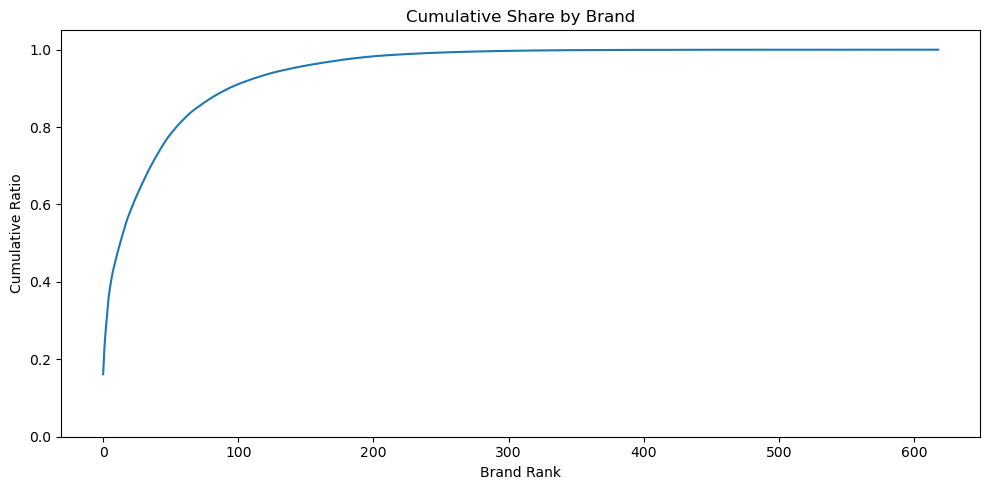

In [83]:
# x축 숫자 라벨 생성 (1부터 시작)
x_labels = list(range(0, len(brand_sales_2025)))

# 누적 점유율 그래프
plt.figure(figsize=(10, 5))
plt.plot(x_labels, brand_sales_2025['Cumul'])
plt.title("Cumulative Share by Brand")
plt.xlabel("Brand Rank")
plt.ylabel("Cumulative Ratio")
plt.ylim(0, 1.05)

# x축 라벨을 100 단위로 설정
step = 100
plt.xticks(ticks=x_labels[::step], labels=x_labels[::step])

plt.tight_layout()
plt.show()

In [45]:
print(brand_sales_2025)

       Brand_raw   RetailSales         Ratio     Cumul
610        ZINUS  1.401663e+08  1.614926e-01  0.161493
386      NOVILLA  6.276125e+07  7.231037e-02  0.233803
168          FDW  3.963378e+07  4.566406e-02  0.279467
352        MLILY  3.545190e+07  4.084590e-02  0.320313
375       NECTAR  3.312092e+07  3.816027e-02  0.358473
..           ...           ...           ...       ...
547      THINMAY  4.999000e+01  5.759598e-08  1.000000
217       HOKWAY  4.999000e+01  5.759598e-08  1.000000
324   MASTERMARK  4.299000e+01  4.953093e-08  1.000000
90       COCOARM  3.412000e+01  3.931136e-08  1.000000
331  MAXXI CLEAN  2.600000e+01  2.995590e-08  1.000000

[619 rows x 4 columns]


### 2. 시장 규모 추이

In [177]:
df1 = df.copy()

In [179]:
df1

,RetailerSku,category,subcategory,profile,size,bsr_ctgry_label,Brand_raw,Brand_adj,Title,WeekEnding,...,UnitsSold,RetailPrice,yr_quarter,yr_month,yr_week,week_str,retailsales_ctgry_brand,retailsales_ctgry_brand_by_6month,year,yr_half
0,B07KNGW8BX,Spring Mattress,Bonnell,8,Full,01. Mattresses,SOMETTE,SOMETTE,#6000 276 Coil Hinged Full Mattress Suede Navy...,2024-05-25,...,5,226.49,24-2,24-05,Y24 W21,Y24 W21,5564.07,0.00,2024,24-H1
1,B07KNGW8BX,Spring Mattress,Bonnell,8,Full,01. Mattresses,SOMETTE,SOMETTE,#6000 276 Coil Hinged Full Mattress Suede Navy...,2023-05-20,...,6,269.90,23-2,23-05,Y23 W20,Y23 W20,5564.07,0.00,2023,23-H1
2,B09JP9N6GL,Spring Mattress,Bonnell,12,Queen,01. Mattresses,NUTAN,NUTAN,12-Inch Medium Plush Double Sided Pillowtop In...,2024-02-17,...,1,535.91,24-1,24-02,Y24 W07,Y24 W07,1777370.72,57507.28,2024,24-H1
3,B0D8Q1VNN8,Spring Mattress,Bonnell,6,Twin,01. Mattresses,OUUI,OUUI,"6 Inch Foam and Spring Hybrid Mattress, Fiberg...",2025-01-25,...,2,119.99,25-1,25-01,Y25 W04,Y25 W04,7940523.10,1119589.42,2025,25-H1
4,B0BBHF5321,Spring Mattress,Bonnell,8,Full,01. Mattresses,BIZCHAIR,BIZCHAIR,8 Inch CertiPUR-US Certified Spring Hybrid Mat...,2025-02-01,...,1,129.99,25-1,25-01,Y25 W05,Y25 W05,345848.68,51044.64,2025,25-H1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
518298,B0DLGTYD9Q,Spring Mattress,Pocket Spring,10,Twin,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Twin Size Mattress, 10 Inch Twin Mattr...",2024-11-16,...,76,69.99,24-4,24-11,Y24 W46,Y24 W46,2862281.93,38397.37,2024,24-H2
518299,B0DLGTYD9Q,Spring Mattress,Pocket Spring,10,Twin,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Twin Size Mattress, 10 Inch Twin Mattr...",2024-11-09,...,2,150.13,24-4,24-11,Y24 W45,Y24 W45,2862281.93,38397.37,2024,24-H2
518300,B0DLGGCVSH,Spring Mattress,Pocket Spring,12,Twin,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Twin Size Mattress, 12 Inch Twin Mattr...",2024-11-09,...,2,250.05,24-4,24-11,Y24 W45,Y24 W45,2862281.93,38397.37,2024,24-H2
518301,B0DLGGCVSH,Spring Mattress,Pocket Spring,12,Twin,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Twin Size Mattress, 12 Inch Twin Mattr...",2024-11-16,...,2,199.99,24-4,24-11,Y24 W46,Y24 W46,2862281.93,38397.37,2024,24-H2


In [209]:
df1.groupby(['year'])['RetailSales'].sum()

year
2023    1.750029e+09
2024    1.863939e+09
2025    8.679426e+08
Name: RetailSales, dtype: float64

In [119]:
df1_grp = df1.groupby(['subcategory'], as_index=False)['RetailSales'].sum()
total = df1['RetailSales'].sum()
df1_grp['Ratio'] = df1_grp['RetailSales']/total*100
print(df1_grp)

       subcategory   RetailSales      Ratio
0          Bonnell  2.169523e+08   4.840620
1  Continuous Coil  5.484140e+03   0.000122
2      Cooling/Gel  1.596857e+09  35.628929
3      Non-Cooling  8.181047e+08  18.253479
4           OTHERS  2.786398e+08   6.216987
5    Pocket Spring  1.571352e+09  35.059861
6             null  7.959000e+01   0.000002


#### 2.1 파이 차트

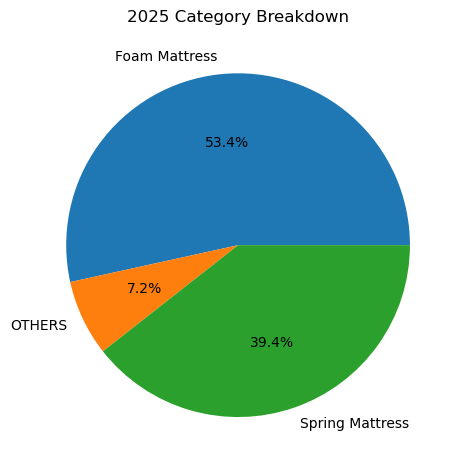

In [223]:
# 1. category별 매출 합계 집계
category_sales = df_2025.groupby('category')['RetailSales'].sum()

# 2. Pie Chart
category_sales.plot(kind='pie', autopct='%1.1f%%', ylabel='', title='2025 Category Breakdown')
plt.tight_layout()
plt.show()

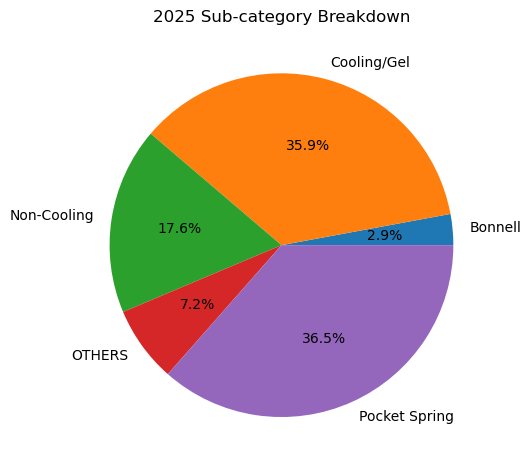

In [225]:
# 1. category별 매출 합계 집계
category_sales = df_2025.groupby('subcategory')['RetailSales'].sum()

# 2. Pie Charts
category_sales.plot(kind='pie', autopct='%1.1f%%', ylabel='', title='2025 Sub-category Breakdown')
plt.tight_layout()
plt.show()

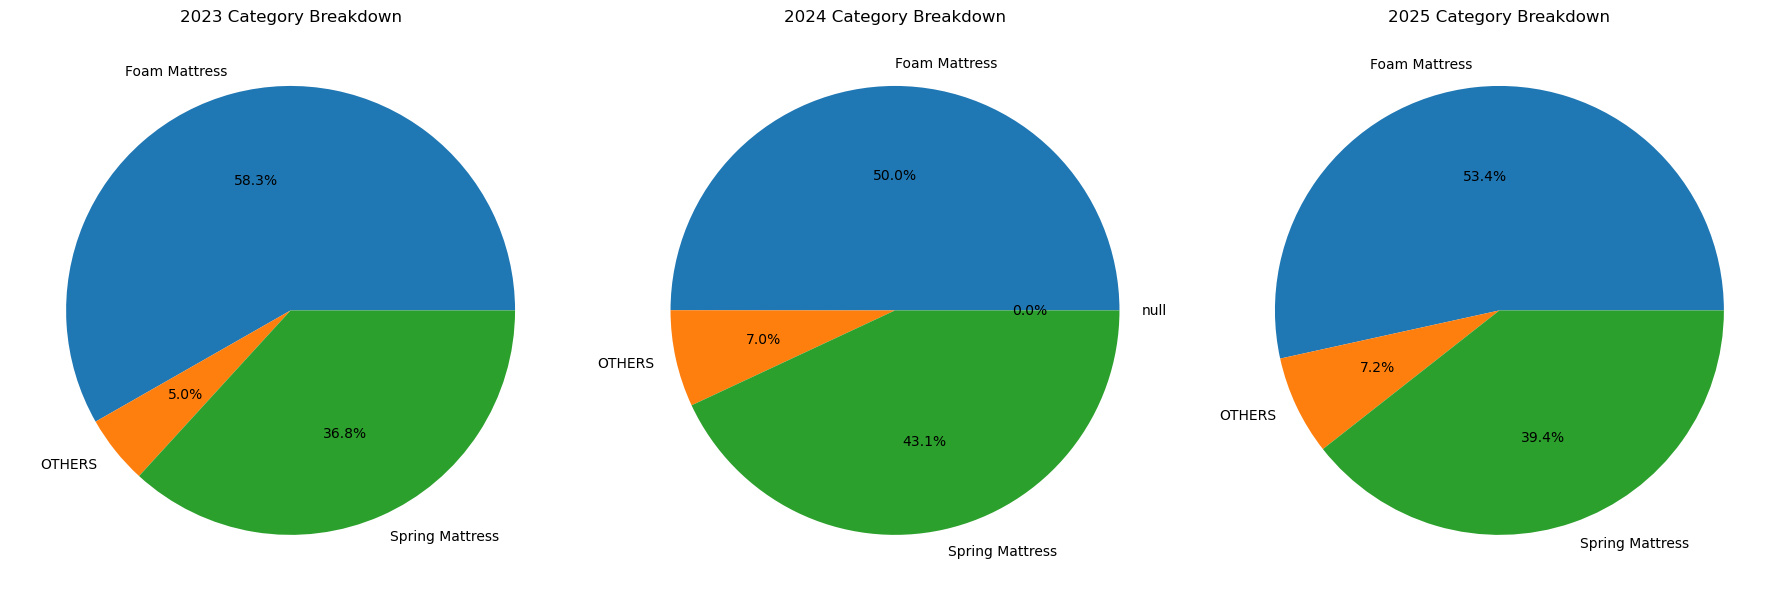

In [240]:

years = [2023, 2024, 2025]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, year in enumerate(years):
    # 해당 연도 데이터 추출
    df_year = df[df['year'] == year]
    # subcategory별 매출 합계
    category_sales = df_year.groupby('category')['RetailSales'].sum()
    
    # 파이차트 그리기
    category_sales.plot(
        kind='pie',
        autopct='%1.1f%%',
        ylabel='',
        title=f'{year} Category Breakdown',
        ax=axes[i]
    )

plt.tight_layout()
plt.show()

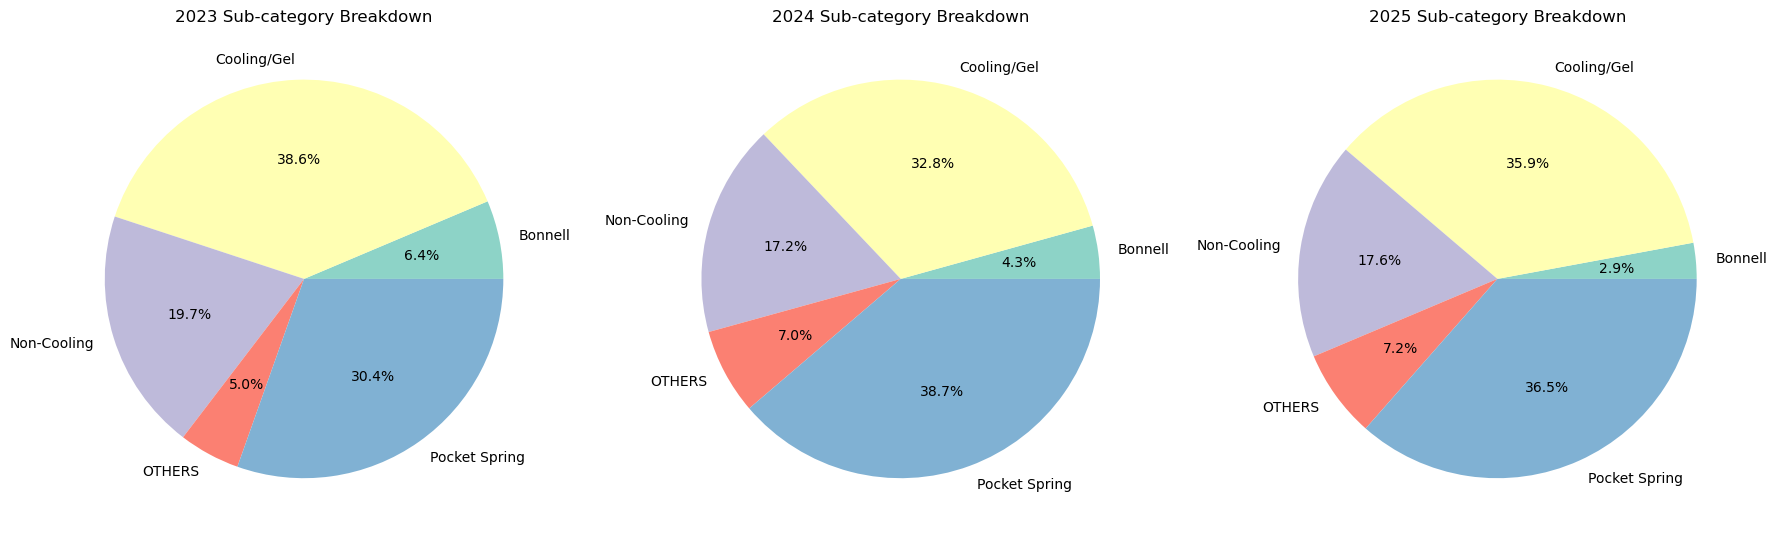

In [238]:
# 연도별 데이터 필터링 및 집계
years = [2023, 2024, 2025]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 모든 subcategory 목록 생성 (특정 카테고리 및 null 값 제외)
all_subcategories = df[~df['subcategory'].isin(['Continuous Coil', 'null']) & 
                      df['subcategory'].notna()]['subcategory'].unique()
colors = plt.cm.Set3(range(len(all_subcategories)))
color_map = dict(zip(all_subcategories, colors))

for i, year in enumerate(years):
    # 해당 연도 데이터 필터링 및 특정 카테고리, null 값 제외
    df_year = df[(df['year'] == year) & 
                 (~df['subcategory'].isin(['Continuous Coil', 'null'])) &
                 (df['subcategory'].notna())]
    
    # category별 매출 합계 집계
    category_sales = df_year.groupby('subcategory')['RetailSales'].sum()
    
    # 해당 연도 subcategory에 맞는 색상 리스트 생성
    pie_colors = [color_map[cat] for cat in category_sales.index]
    
    # Pie Chart 생성
    category_sales.plot(kind='pie', 
                       ax=axes[i],
                       autopct='%1.1f%%', 
                       ylabel='', 
                       title=f'{year} Sub-category Breakdown',
                       colors=pie_colors)

plt.tight_layout()
plt.show()

#### 2.2 영역 차트

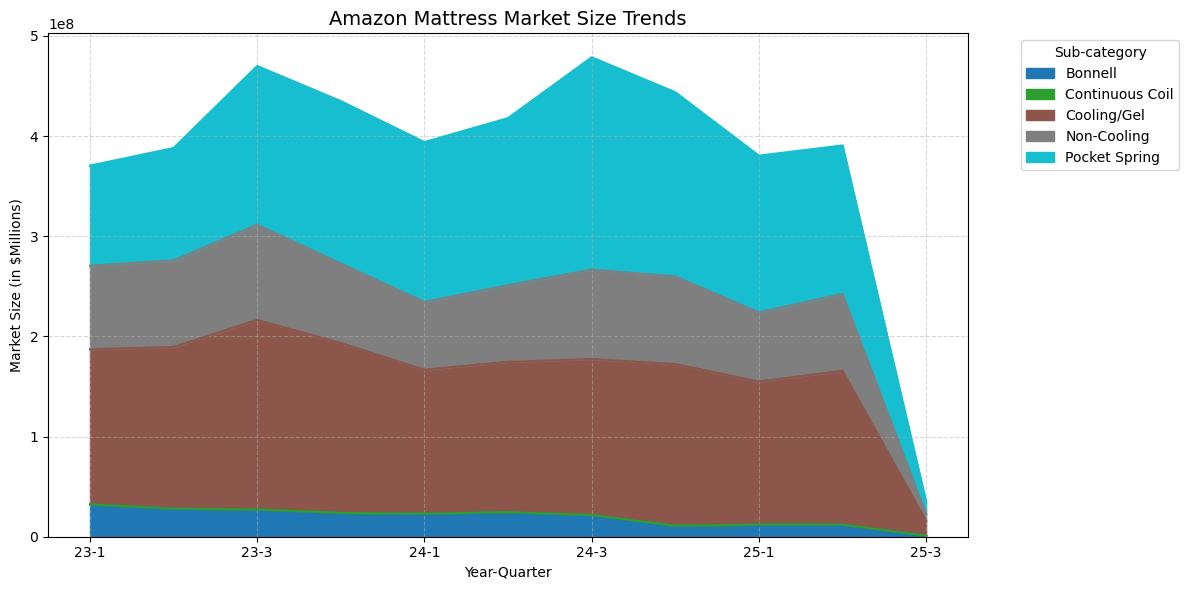

In [211]:
# 1. 'Others'와 null category 제외
df_filtered = df1[(df1['subcategory'] != 'null') & (df1['category'] != 'OTHERS')]
# 2. 세부 카테고리별 월간 매출 합계 집계
df_grouped = df_filtered.groupby(['yr_quarter', 'subcategory'])['RetailSales'].sum().unstack().fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))  # ✅ 두 개(Figure, Axes)를 반환
df_grouped.plot(kind='area', stacked=True, colormap='tab10', ax=ax)

ax.set_title('Amazon Mattress Market Size Trends', fontsize=14)
ax.set_xlabel('Year-Quarter')
ax.set_ylabel('Market Size (in $Millions)')
ax.legend(title='Sub-category', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### 2.3 Inch별 파이차트 / 영역 차트

In [261]:
df1

,RetailerSku,category,subcategory,profile,size,bsr_ctgry_label,Brand_raw,Brand_adj,Title,WeekEnding,...,UnitsSold,RetailPrice,yr_quarter,yr_month,yr_week,week_str,retailsales_ctgry_brand,retailsales_ctgry_brand_by_6month,year,yr_half
0,B07KNGW8BX,Spring Mattress,Bonnell,8,Full,01. Mattresses,SOMETTE,SOMETTE,#6000 276 Coil Hinged Full Mattress Suede Navy...,2024-05-25,...,5,226.49,24-2,24-05,Y24 W21,Y24 W21,5564.07,0.00,2024,24-H1
1,B07KNGW8BX,Spring Mattress,Bonnell,8,Full,01. Mattresses,SOMETTE,SOMETTE,#6000 276 Coil Hinged Full Mattress Suede Navy...,2023-05-20,...,6,269.90,23-2,23-05,Y23 W20,Y23 W20,5564.07,0.00,2023,23-H1
2,B09JP9N6GL,Spring Mattress,Bonnell,12,Queen,01. Mattresses,NUTAN,NUTAN,12-Inch Medium Plush Double Sided Pillowtop In...,2024-02-17,...,1,535.91,24-1,24-02,Y24 W07,Y24 W07,1777370.72,57507.28,2024,24-H1
3,B0D8Q1VNN8,Spring Mattress,Bonnell,6,Twin,01. Mattresses,OUUI,OUUI,"6 Inch Foam and Spring Hybrid Mattress, Fiberg...",2025-01-25,...,2,119.99,25-1,25-01,Y25 W04,Y25 W04,7940523.10,1119589.42,2025,25-H1
4,B0BBHF5321,Spring Mattress,Bonnell,8,Full,01. Mattresses,BIZCHAIR,BIZCHAIR,8 Inch CertiPUR-US Certified Spring Hybrid Mat...,2025-02-01,...,1,129.99,25-1,25-01,Y25 W05,Y25 W05,345848.68,51044.64,2025,25-H1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
518298,B0DLGTYD9Q,Spring Mattress,Pocket Spring,10,Twin,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Twin Size Mattress, 10 Inch Twin Mattr...",2024-11-16,...,76,69.99,24-4,24-11,Y24 W46,Y24 W46,2862281.93,38397.37,2024,24-H2
518299,B0DLGTYD9Q,Spring Mattress,Pocket Spring,10,Twin,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Twin Size Mattress, 10 Inch Twin Mattr...",2024-11-09,...,2,150.13,24-4,24-11,Y24 W45,Y24 W45,2862281.93,38397.37,2024,24-H2
518300,B0DLGGCVSH,Spring Mattress,Pocket Spring,12,Twin,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Twin Size Mattress, 12 Inch Twin Mattr...",2024-11-09,...,2,250.05,24-4,24-11,Y24 W45,Y24 W45,2862281.93,38397.37,2024,24-H2
518301,B0DLGGCVSH,Spring Mattress,Pocket Spring,12,Twin,01. Mattresses,WOOD-IT,WOOD-IT,"wOod-it Twin Size Mattress, 12 Inch Twin Mattr...",2024-11-16,...,2,199.99,24-4,24-11,Y24 W46,Y24 W46,2862281.93,38397.37,2024,24-H2


In [263]:
df1['RetailerSku'].nunique()

23253

In [265]:
profile_grp = (
    df_spring
    .groupby('profile')
    .agg(
        sku_count=('RetailerSku', 'nunique'),
        total_sales=('RetailSales', 'sum')
    )
    .reset_index()
)
print(profile_grp)

   profile  sku_count   total_sales
0     0.06          1  1.598400e+02
1      0.4          2  1.775040e+03
2      0.5          2  1.519712e+04
3     0.75          1  7.264068e+04
4        1          8  9.114790e+03
5     1.18          1  5.278800e+02
6      1.2          1  5.599600e+02
7       10       2115  5.884713e+08
8     10.5         15  1.086520e+06
9       11        142  2.466848e+07
10    11.5         23  5.114745e+06
11   11.81          1  1.079493e+05
12      12       1580  7.750665e+08
13    12.2          2  2.704305e+05
14    12.5          4  5.248202e+04
15      13         97  2.394814e+07
16    13.2          1  3.849970e+03
17    13.5         14  6.493452e+05
18      14        551  2.117752e+08
19    14.5          8  1.053227e+06
20   14.75          1  8.021650e+03
21      15         30  1.663924e+06
22    15.5          3  2.832131e+04
23      16         39  8.147288e+05
24      17          1  1.799880e+03
25      18          1  8.394000e+03
26       2         41  2.047

In [271]:
# profile이 null인 행만 필터링
df_null_profile = df_mattress[df_mattress['profile'] == 'null']

# 결과 확인 (상위 5개만 예시)
print(df_null_profile.head())

       RetailerSku         category  subcategory profile  \
1263    B0CRJYHBBV  Spring Mattress      Bonnell    null   
178688  B0CCQWBJR1    Foam Mattress  Cooling/Gel    null   
178752  B0CCK922CG    Foam Mattress  Cooling/Gel    null   
178754  B0CCK9H53L    Foam Mattress  Cooling/Gel    null   
178755  B0CCK922CD    Foam Mattress  Cooling/Gel    null   

                         size bsr_ctgry_label          Brand_raw  \
1263                     null  01. Mattresses  DREAMFOAM BEDDING   
178688  Split California King  01. Mattresses           IDEALBED   
178752                   Full  01. Mattresses           IDEALBED   
178754                  Queen  01. Mattresses           IDEALBED   
178755                Twin XL  01. Mattresses           IDEALBED   

                Brand_adj                                              Title  \
1263    DREAMFOAM BEDDING  DREAMFOAM Spring Dreams Ultra Firm Double Side...   
178688           IDEALBED  iDealBed G4 Nova Luxury Memory Foam Mattres

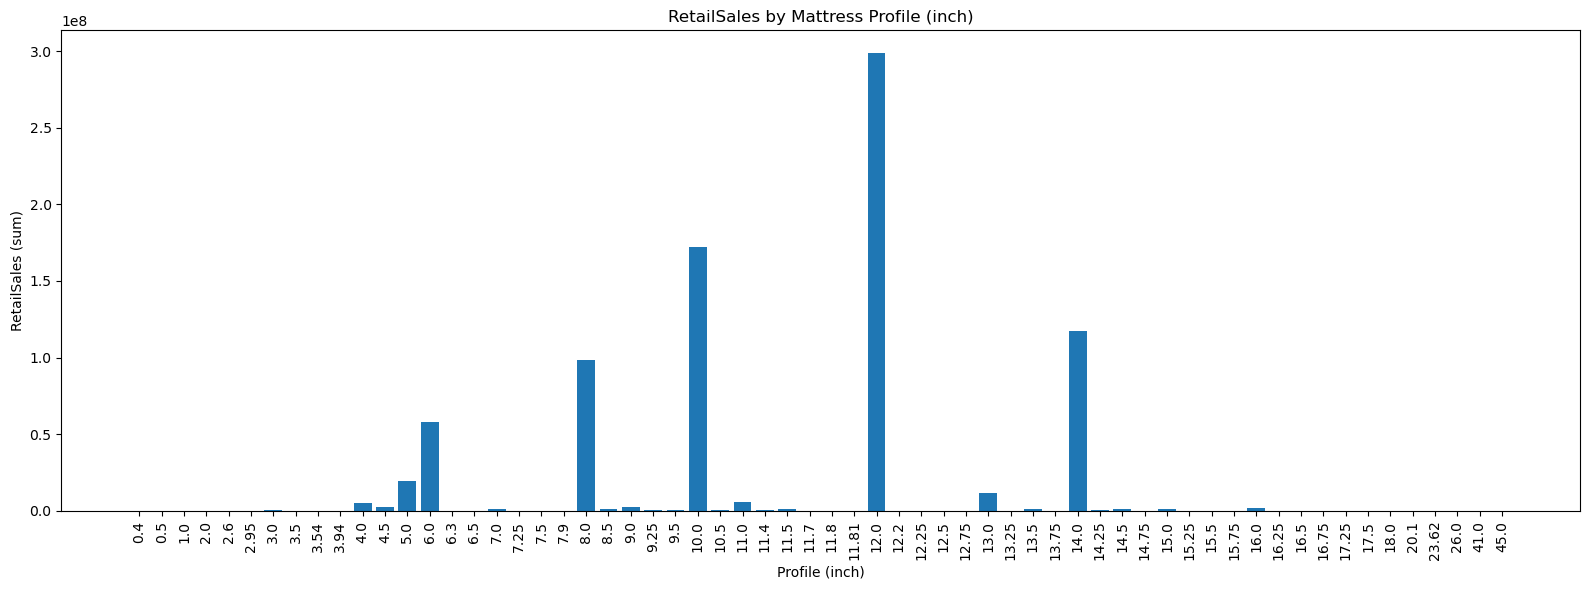

In [279]:
# 2025년 데이터 필터링 (df1에서)
df_mattress = df1[df1['year']==2025].copy()

# profile 값 전처리
df_mattress['profile'] = pd.to_numeric(df_mattress['profile'], errors='coerce')
df_mattress = df_mattress[df_mattress['profile'].notnull()]

# 각 profile(inch) 별 RetailSales 합계 집계
sales_by_profile = (
    df_mattress
    .groupby('profile')['RetailSales']
    .sum()
    .reset_index()
    .sort_values('profile')
)

# Plot
plt.figure(figsize=(16, 6))
plt.bar(sales_by_profile['profile'].astype(str), sales_by_profile['RetailSales'])
plt.xlabel('Profile (inch)')
plt.ylabel('RetailSales (sum)')
plt.title('RetailSales by Mattress Profile (inch)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

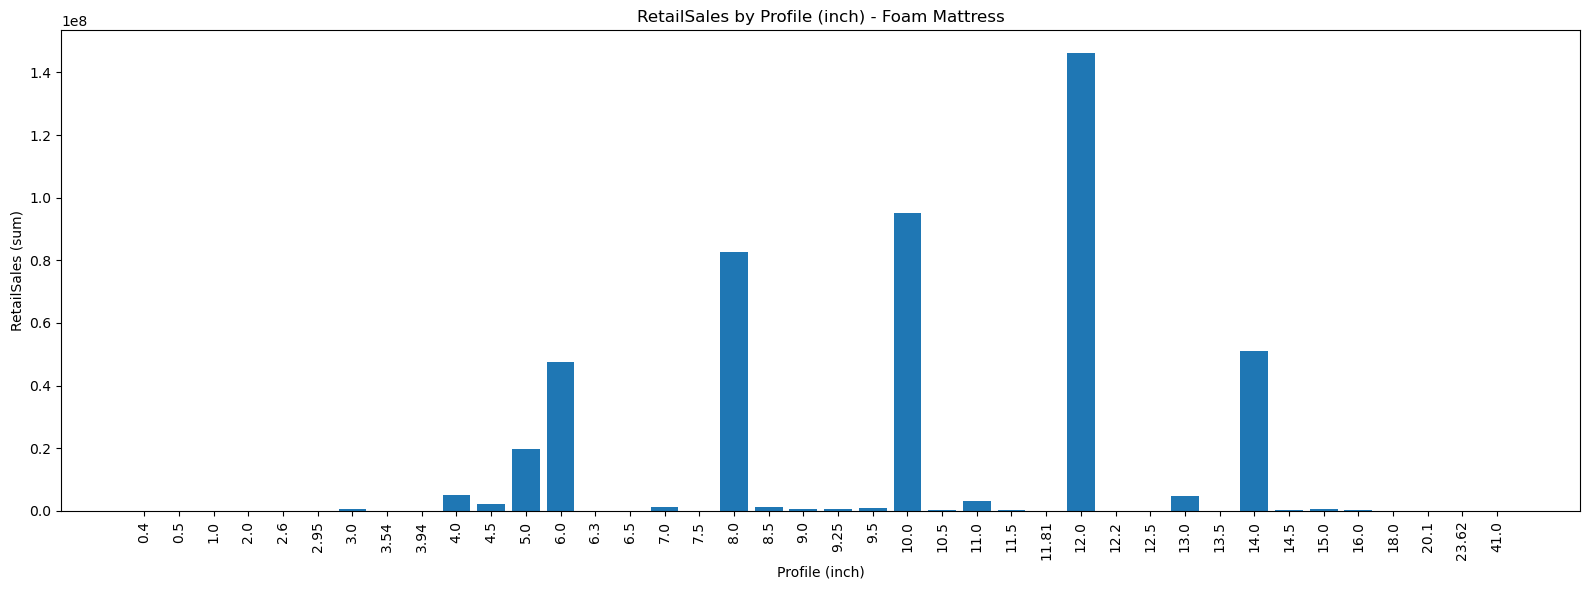

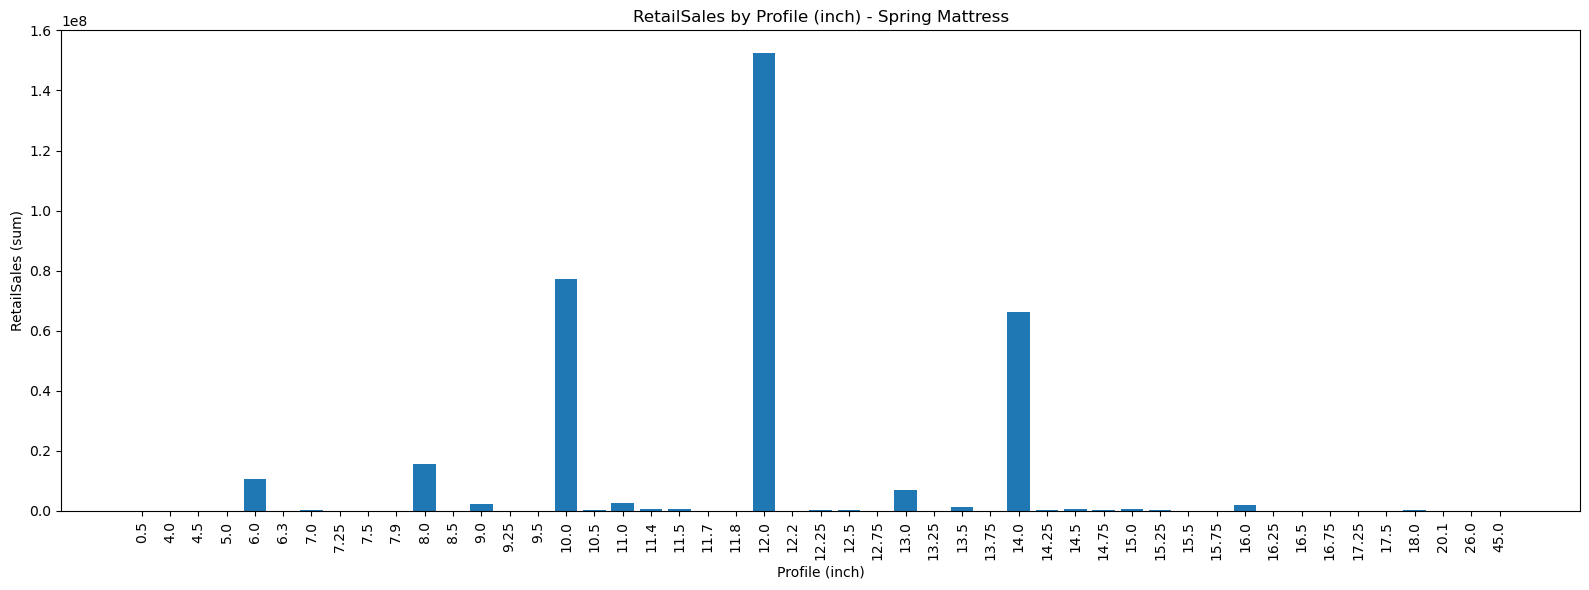

In [281]:
# 2025년 데이터 필터링
df_mattress = df1[df1['year']==2025].copy()

# profile 값 전처리
df_mattress['profile'] = pd.to_numeric(df_mattress['profile'], errors='coerce')
df_mattress = df_mattress[df_mattress['profile'].notnull()]

# 각 카테고리별로 반복
for cat in ['Foam Mattress', 'Spring Mattress']:
    df_cat = df_mattress[df_mattress['category'] == cat]

    sales_by_profile = (
        df_cat
        .groupby('profile')['RetailSales']
        .sum()
        .reset_index()
        .sort_values('profile')
    )

    plt.figure(figsize=(16, 6))
    plt.bar(sales_by_profile['profile'].astype(str), sales_by_profile['RetailSales'])
    plt.xlabel('Profile (inch)')
    plt.ylabel('RetailSales (sum)')
    plt.title(f'RetailSales by Profile (inch) - {cat}')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

#### 2.4 Size별 분석하기

In [86]:
#df1 = df.copy()
df_2025 = df[df['year'] == 2025].copy()

In [88]:
size_group = (
    df_2025.groupby('size')
    .agg(sku_count=('RetailerSku','nunique'), total_sales=('RetailSales','sum'))
    .reset_index()
    .sort_values(by='total_sales', ascending=False)
)

print(size_group)

          size  sku_count   total_sales
5        Queen       2665  3.085028e+08
2         King       1852  1.680019e+08
1         Full       2131  1.595589e+08
6         Twin       2011  1.341659e+08
4       OTHERS       2674  6.320890e+07
7      Twin XL        802  2.010014e+07
0     Cal King        511  1.228836e+07
3  Narrow Twin         91  2.115705e+06


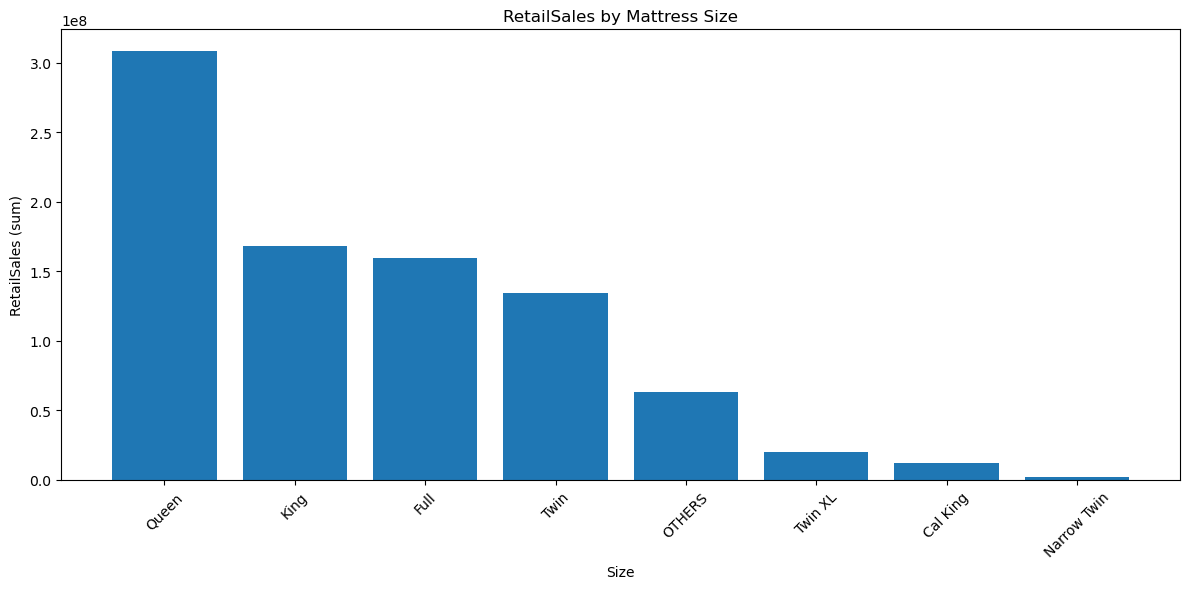

In [90]:
# sku_count가 1 초과인 경우만 필터링
#size_group = size_group[size_group['sku_count'] > 5]
plt.figure(figsize=(12, 6))
plt.bar(size_group['size'].astype(str), size_group['total_sales'])
plt.xlabel('Size')
plt.ylabel('RetailSales (sum)')
plt.title('RetailSales by Mattress Size')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

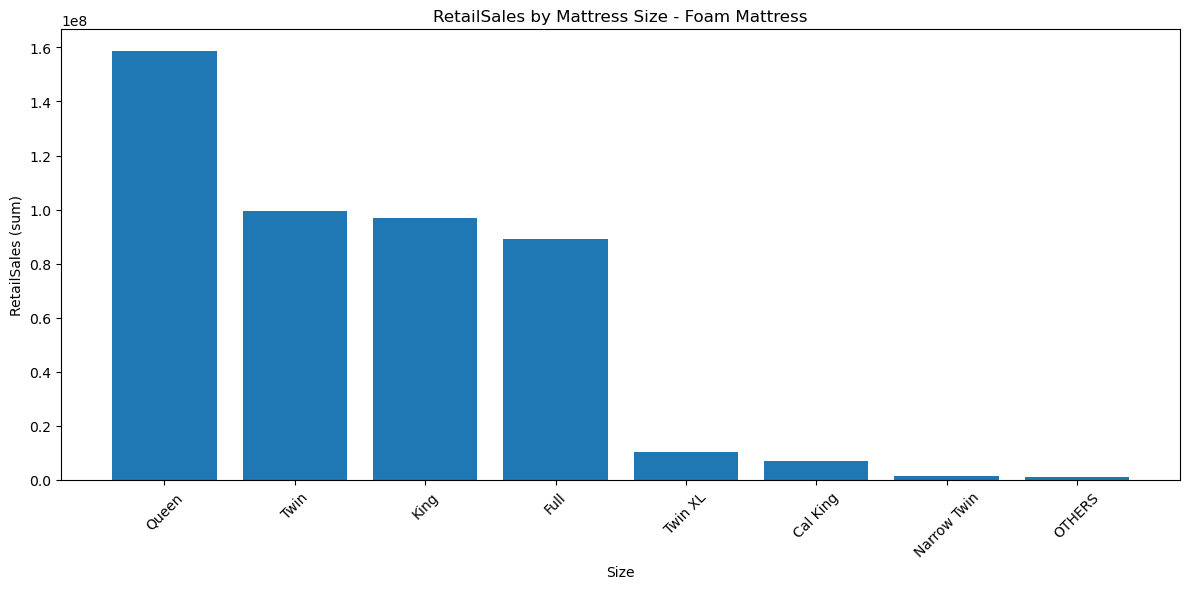

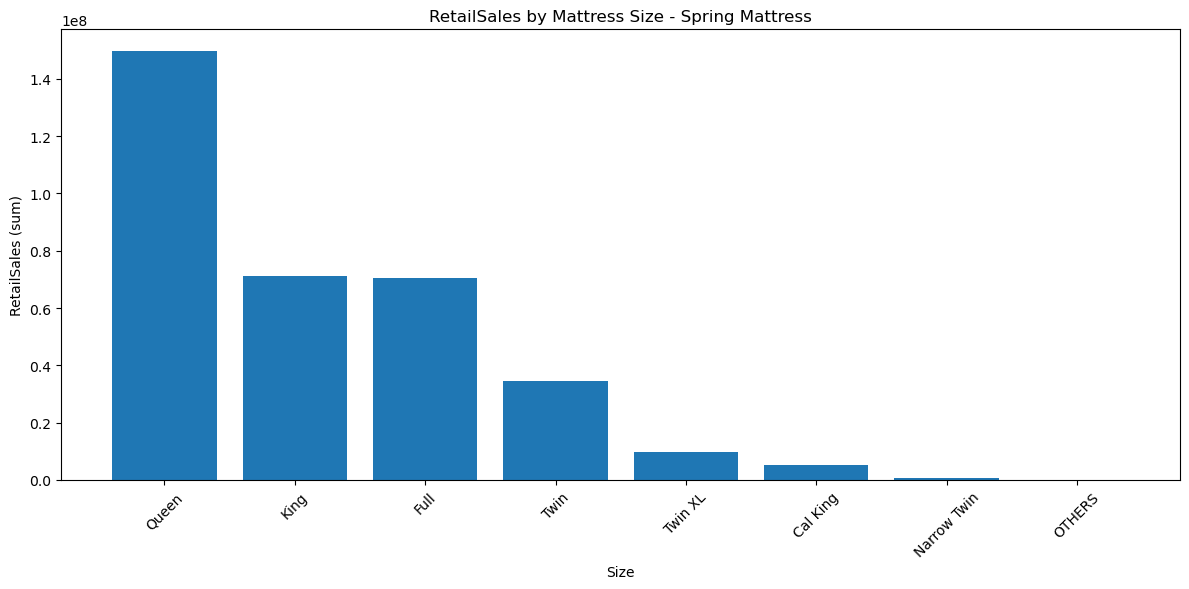

In [92]:
# Foam과 Spring으로 분리해서 처리
for cat in ['Foam Mattress', 'Spring Mattress']:
    df_cat = df_2025[df_2025['category'] == cat]

    # size별 sku 수와 매출 집계
    size_group = (
        df_cat.groupby('size')
        .agg(sku_count=('RetailerSku', 'nunique'),
             total_sales=('RetailSales', 'sum'))
        .reset_index()
        .sort_values(by='total_sales', ascending=False)
    )

    # 시각화
    plt.figure(figsize=(12, 6))
    plt.bar(size_group['size'].astype(str), size_group['total_sales'])
    plt.xlabel('Size')
    plt.ylabel('RetailSales (sum)')
    plt.title(f'RetailSales by Mattress Size - {cat}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 3. Price 분석

#### 3.1 가격 분석 (KDE)

In [101]:
df1 = df.copy()

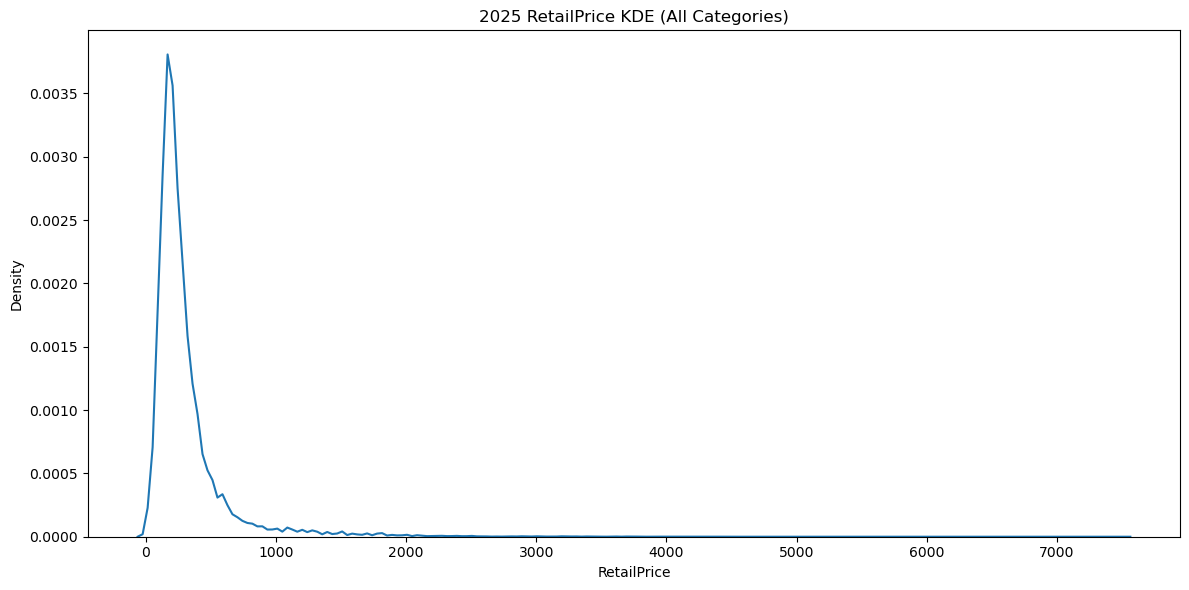

In [109]:
# 2025년 데이터만 필터링
df_2025 = df1[df1['year'] == 2025]

plt.figure(figsize=(12, 6))

# KDE 플롯 (log 변환 없이)
prices = df_2025['RetailPrice'].dropna()
prices = prices[prices > 0]
sns.kdeplot(prices, bw_adjust=0.7)

plt.xlabel('RetailPrice')
plt.ylabel('Density')
plt.title('2025 RetailPrice KDE (All Categories)')
plt.tight_layout()
plt.show()

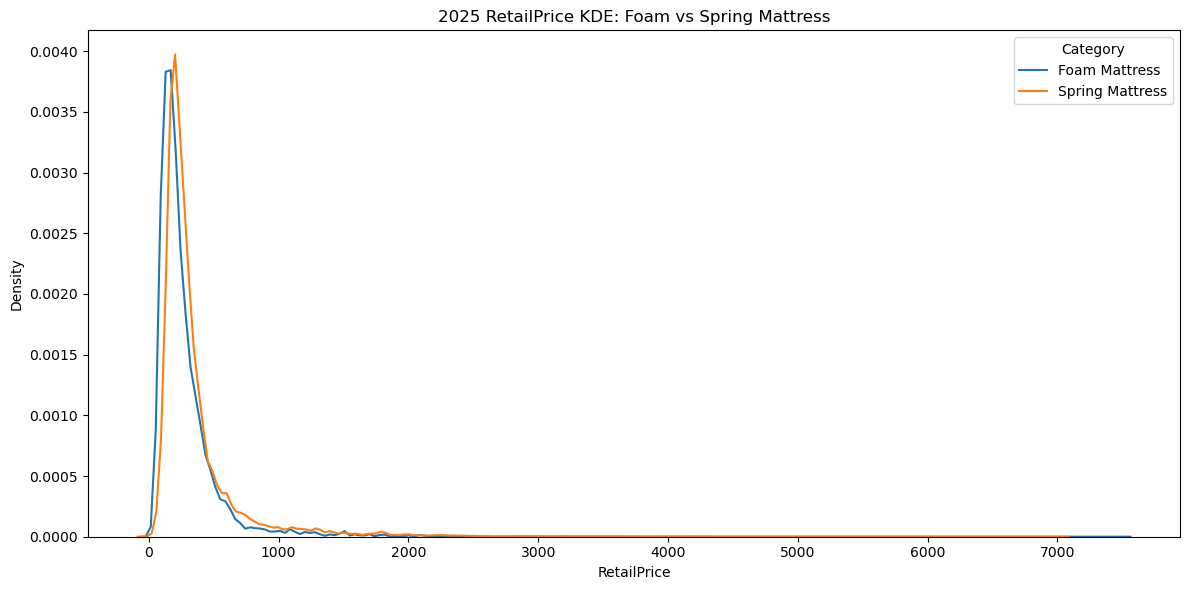

In [111]:
# 2025년 + Foam/Spring만 추출
df_2025 = df1[df1['year'] == 2025]
target_cats = ['Foam Mattress', 'Spring Mattress']
df_2025 = df_2025[df_2025['category'].isin(target_cats)]

plt.figure(figsize=(12, 6))

# Foam/Spring 각각 KDE 그리기 (로그 변환 없이)
for cat in target_cats:
    prices = df_2025[df_2025['category'] == cat]['RetailPrice'].dropna()
    prices = prices[prices > 0]
    sns.kdeplot(prices, label=cat, bw_adjust=0.7)

plt.xlabel('RetailPrice')
plt.ylabel('Density')
plt.title('2025 RetailPrice KDE: Foam vs Spring Mattress')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

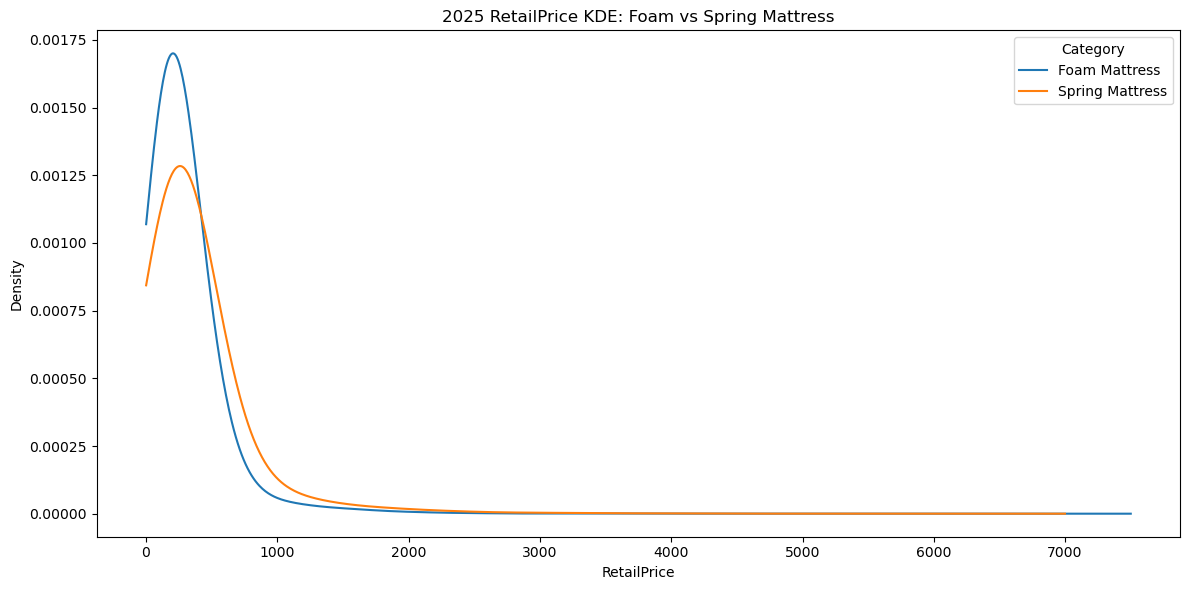

Foam Mattress에서 Density peak가 가장 높은 가격: $203.68
Spring Mattress에서 Density peak가 가장 높은 가격: $260.19


In [113]:
from scipy.stats import gaussian_kde

# 2025년 + Foam/Spring만 추출
df_2025 = df1[df1['year'] == 2025]
target_cats = ['Foam Mattress', 'Spring Mattress']
df_2025 = df_2025[df_2025['category'].isin(target_cats)]

plt.figure(figsize=(12, 6))

peak_prices = {}

for cat in target_cats:
    prices = df_2025[df_2025['category'] == cat]['RetailPrice'].dropna()
    prices = prices[prices > 0]

    # KDE 곡선 직접 계산
    kde = gaussian_kde(prices, bw_method=0.7)
    x_grid = np.linspace(prices.min(), prices.max(), 1000)
    density = kde(x_grid)

    # 그래프
    plt.plot(x_grid, density, label=cat)

    # 최대값 위치(peak) 구하기
    peak_idx = np.argmax(density)
    peak_price = x_grid[peak_idx]
    peak_prices[cat] = peak_price

plt.xlabel('RetailPrice')
plt.ylabel('Density')
plt.title('2025 RetailPrice KDE: Foam vs Spring Mattress')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

# 결과 출력
for cat in target_cats:
    print(f"{cat}에서 Density peak가 가장 높은 가격: ${peak_prices[cat]:,.2f}")

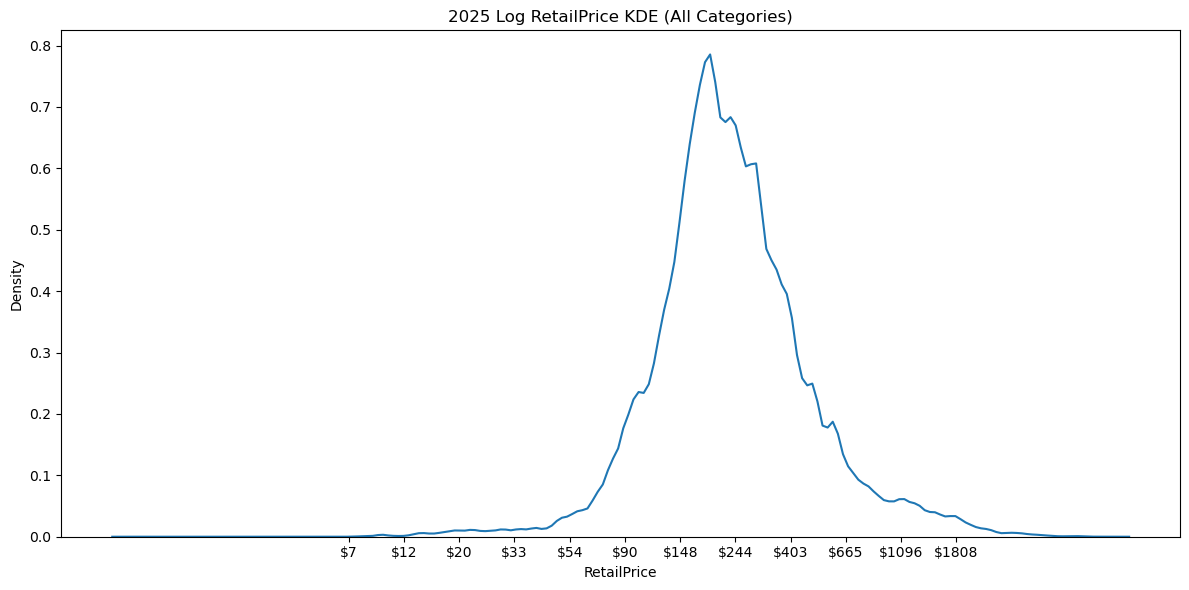

In [105]:
# 2025년 데이터만 필터링
df_2025 = df1[df1['year'] == 2025]

plt.figure(figsize=(12, 6))

# KDE 플롯
prices = df_2025['RetailPrice'].dropna()
prices = prices[prices > 0]
log_prices = np.log(prices)
sns.kdeplot(log_prices, bw_adjust=0.7)

# 로그축 x → 실제 가격으로 표시
xticks = np.arange(2, 8, 0.5)  # log(가격) 범위 설정
xtick_labels = [f"${int(np.exp(x))}" for x in xticks]

plt.xticks(xticks, xtick_labels)
plt.xlabel('RetailPrice')
plt.ylabel('Density')
plt.title('2025 Log RetailPrice KDE (All Categories)')
plt.tight_layout()
plt.show()

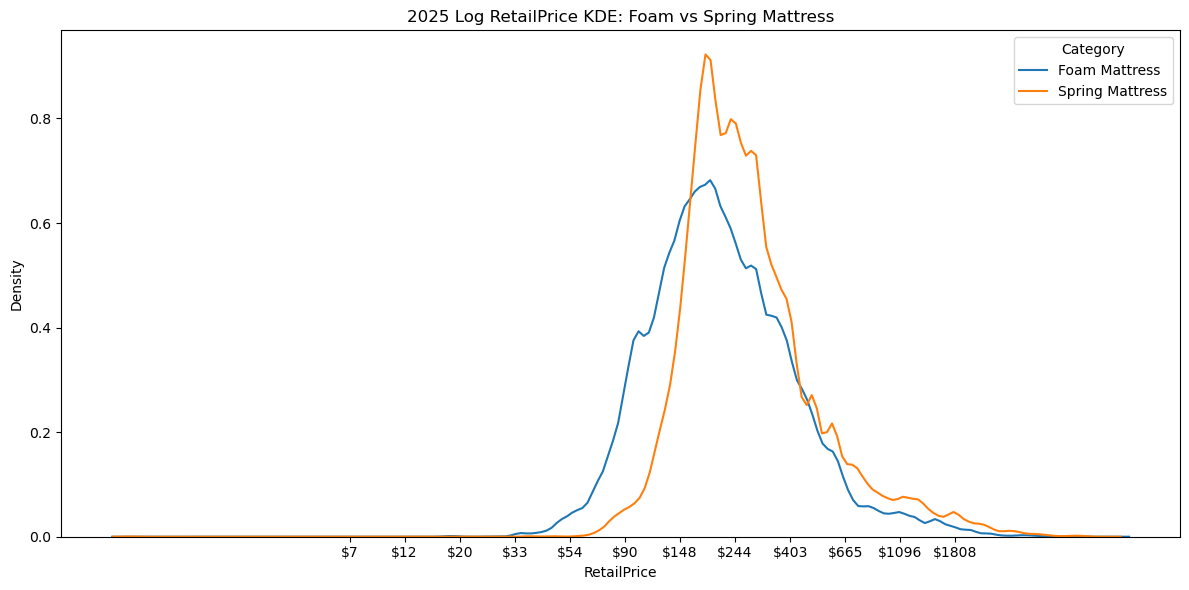

In [107]:
# 2025년 + Foam/Spring만 추출
df_2025 = df1[df1['year'] == 2025]
target_cats = ['Foam Mattress', 'Spring Mattress']
df_2025 = df_2025[df_2025['category'].isin(target_cats)]

plt.figure(figsize=(12, 6))

# Foam/Spring 각각 KDE 그리기
for cat in target_cats:
    prices = df_2025[df_2025['category'] == cat]['RetailPrice'].dropna()
    prices = prices[prices > 0]
    log_prices = np.log(prices)
    sns.kdeplot(log_prices, label=cat, bw_adjust=0.7)

# 로그축 x → 실제 가격으로 표시
xticks = np.arange(2, 8, 0.5)  # log(가격) 범위 설정
xtick_labels = [f"${int(np.exp(x))}" for x in xticks]

plt.xticks(xticks, xtick_labels)
plt.xlabel('RetailPrice')
plt.ylabel('Density')
plt.title('2025 Log RetailPrice KDE: Foam vs Spring Mattress')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

In [ ]:
# 2025년 데이터만 필터링
df_2025 = df[df['year'] == 2025]

# 카테고리별 반복
for category, cat_group in df.groupby('category'):
    plt.figure(figsize=(12, 6))

    # 연도별 반복
    for year, group in cat_group.groupby('year'):
        prices = group['RetailPrice'].dropna()
        prices = prices[prices > 0]
        log_prices = np.log(prices)
        sns.kdeplot(log_prices, label=year, bw_adjust=0.7)

    # 로그축 x → 실제 가격으로 표시
    xticks = np.arange(2, 8, 0.5)  # log(가격) 범위 설정 (ex: e^2 ≈ $7, e^8 ≈ $2980)
    xtick_labels = [f"${int(np.exp(x))}" for x in xticks]

    plt.xticks(xticks, xtick_labels)
    plt.xlabel('RetailPrice')
    plt.ylabel('Density')
    plt.title(f'Yearly Log RetailPrice KDE - Category: {category}')
    plt.legend(title='Year')
    plt.tight_layout()
    plt.show()

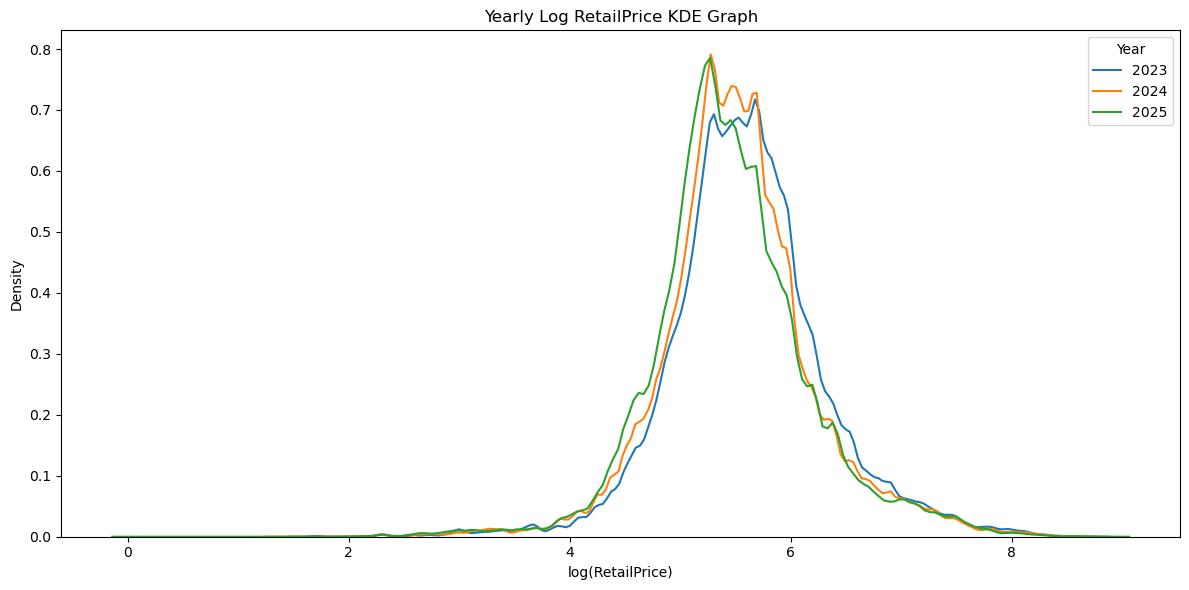

In [116]:
plt.figure(figsize=(12, 6))

# 년도별 반복
for year, group in df1.groupby('year'):
    prices = group['RetailPrice'].dropna()
    prices = prices[prices > 0]
    log_prices = np.log(prices)
    sns.kdeplot(log_prices, label=year, bw_adjust=0.7)


plt.xlabel('log(RetailPrice)')
plt.ylabel('Density')
plt.title('Yearly Log RetailPrice KDE Graph')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

In [122]:
int(np.exp(5.5))

244

#### 3.2 가격대별 히트맵 

In [126]:
df1 = df.copy()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_32980\2561297937.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby('PriceBin')['RetailSales']


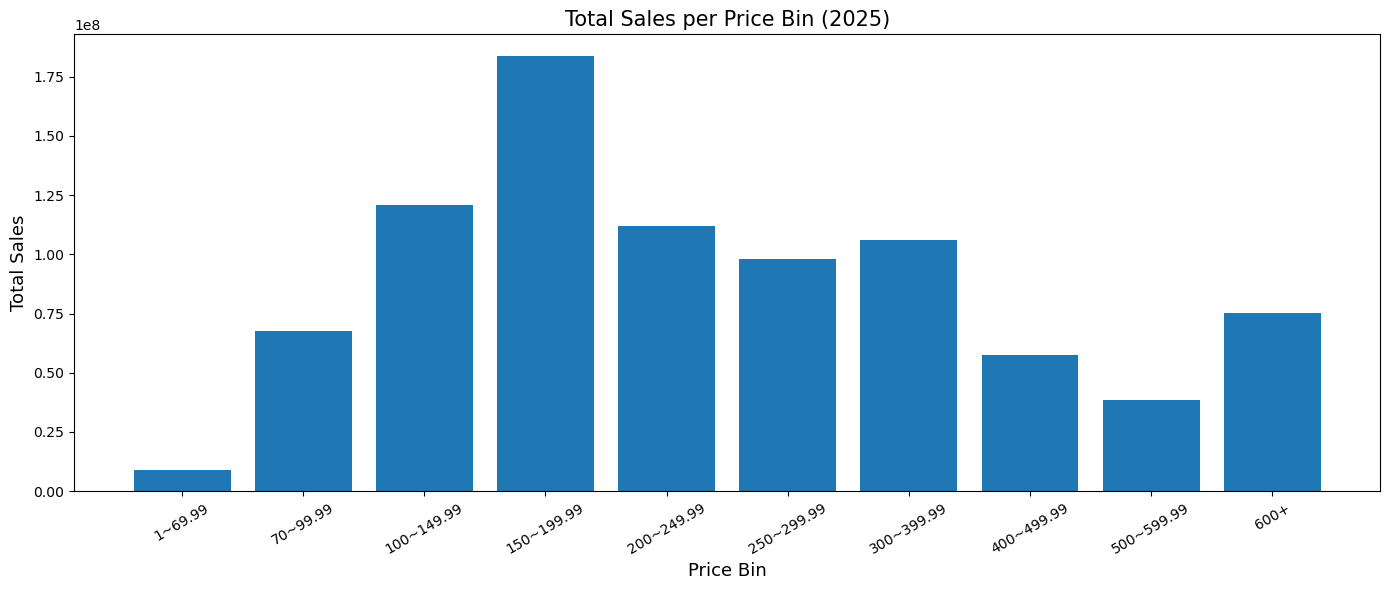

In [130]:
# 1. 2025년 + OTHERS 제외
df_filtered = df1[df['year'] == 2025].copy()

# 2. Price Bin 직접 정의
price_bins = [1, 70, 100, 150, 200, 250, 300, 400, 500, 600, np.inf]
bin_labels = [ "1~69.99", "70~99.99", "100~149.99", "150~199.99",
    "200~249.99", "250~299.99", "300~399.99", "400~499.99",
    "500~599.99", "600+"
]

# 3. 가격 버킷 할당
df_filtered['PriceBin'] = pd.cut(
    df_filtered['RetailPrice'],
    bins=price_bins,
    labels=bin_labels,
    right=False,   # 왼쪽 포함, 오른쪽 미포함 (1~50은 1 <= x < 50)
    include_lowest=True
)

# 4. Price Bin별 매출 합계 집계
sales_by_bin = (
    df_filtered.groupby('PriceBin')['RetailSales']
    #df_filtered.groupby('PriceBin')['UnitsSold']
    .sum()
    .reindex(bin_labels)  # 빈 구간도 포함
)

# 5. 히스토그램(막대그래프) 시각화
plt.figure(figsize=(14,6))
plt.bar(sales_by_bin.index, sales_by_bin.values)
plt.xlabel("Price Bin", fontsize=13)
plt.ylabel("Total Sales", fontsize=13)
plt.title("Total Sales per Price Bin (2025)", fontsize=15)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_32980\278389721.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby('PriceBin')['RetailSales']


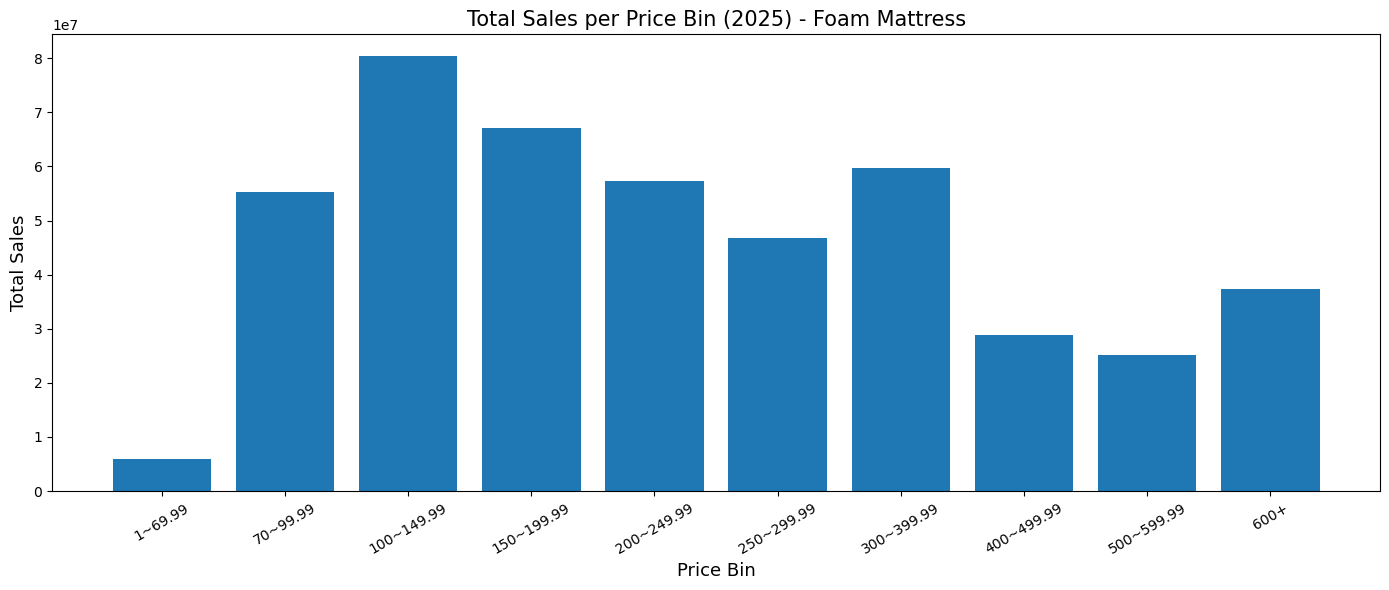

C:\Users\최태욱\AppData\Local\Temp\ipykernel_32980\278389721.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby('PriceBin')['RetailSales']


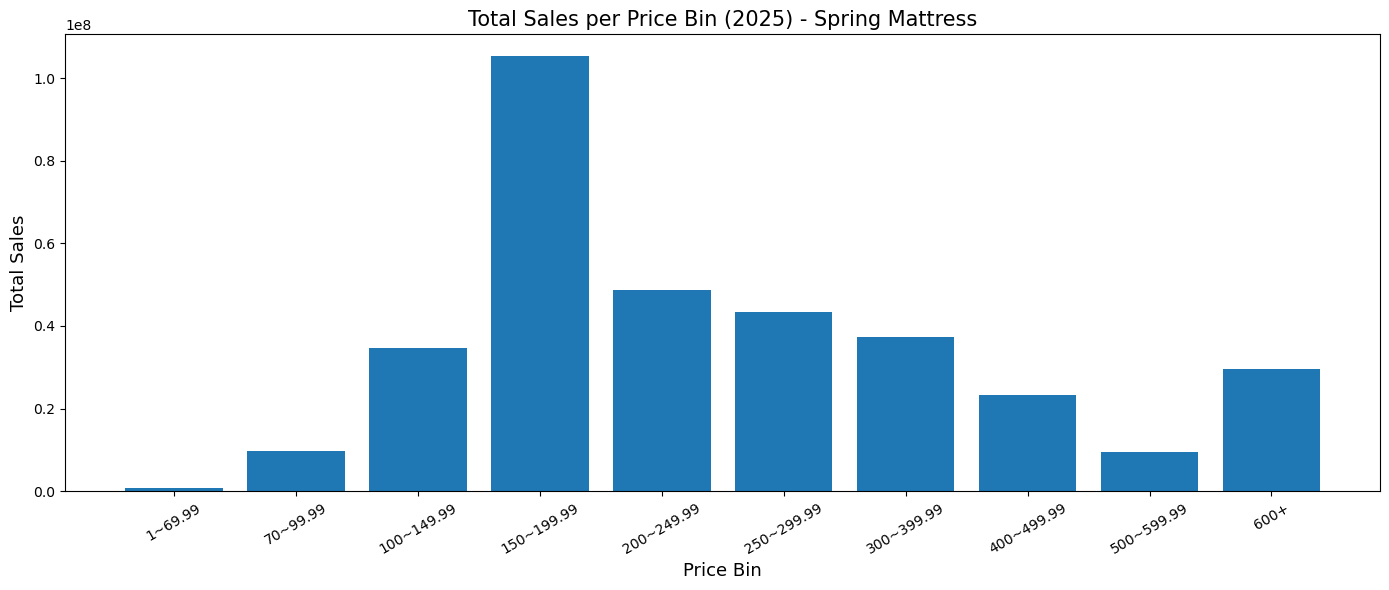

In [132]:
# 1. 2025년 데이터만 + OTHERS 제외
df_filtered = df1[(df1['year'] == 2025) & (df1['category'].isin(['Foam Mattress', 'Spring Mattress']))].copy()

# 2. Price Bin 직접 정의
price_bins = [1, 70, 100, 150, 200, 250, 300, 400, 500, 600, np.inf]
bin_labels = [ "1~69.99", "70~99.99", "100~149.99", "150~199.99",
    "200~249.99", "250~299.99", "300~399.99", "400~499.99",
    "500~599.99", "600+"
]

# 3. 가격 버킷 할당
df_filtered['PriceBin'] = pd.cut(
    df_filtered['RetailPrice'],
    bins=price_bins,
    labels=bin_labels,
    right=False,
    include_lowest=True
)

# 4. Foam/Spring 별로 반복
for cat in ['Foam Mattress', 'Spring Mattress']:
    df_cat = df_filtered[df_filtered['category'] == cat]
    sales_by_bin = (
        df_cat.groupby('PriceBin')['RetailSales']
        .sum()
        .reindex(bin_labels)  # 빈 구간도 포함
    )

    plt.figure(figsize=(14,6))
    plt.bar(sales_by_bin.index, sales_by_bin.values)
    plt.xlabel("Price Bin", fontsize=13)
    plt.ylabel("Total Sales", fontsize=13)
    plt.title(f"Total Sales per Price Bin (2025) - {cat}", fontsize=15)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\271820143.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby(['PriceBin', 'yr_week'])['RetailSales']


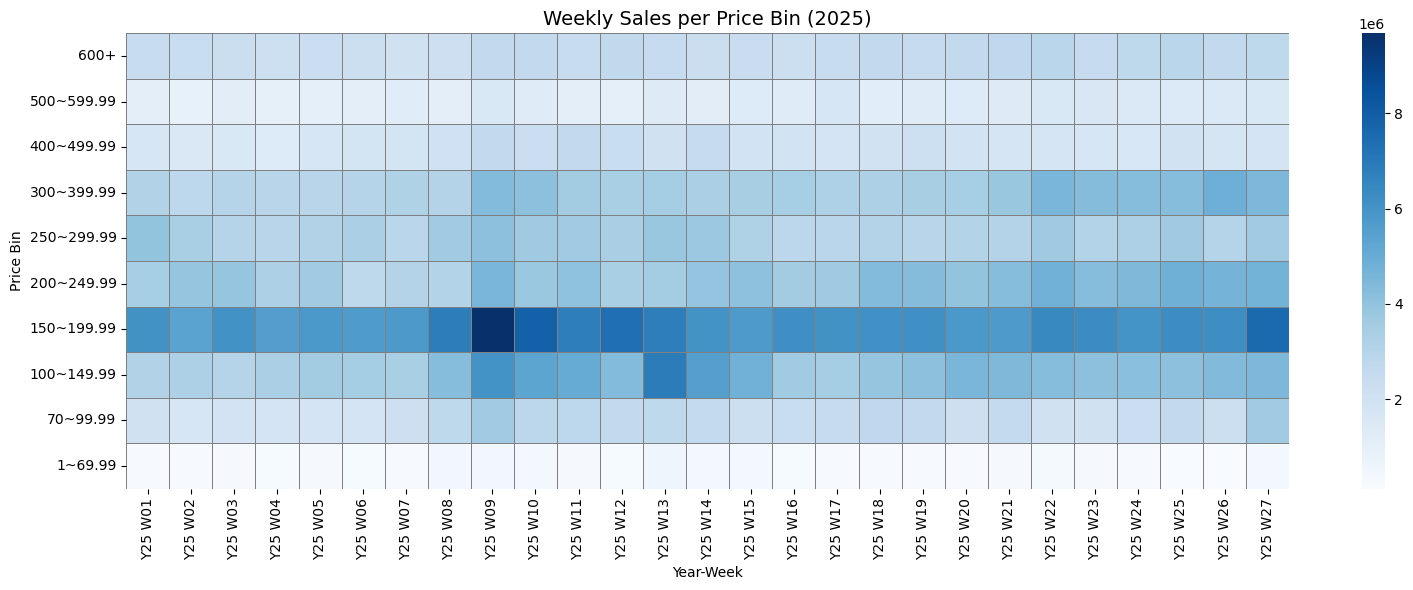

In [194]:
# 1. 2025년 + OTHERS 제외
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025)
].copy()

# 2. Price Bin 직접 정의
price_bins = [1, 70, 100, 150, 200, 250, 300, 400, 500, 600, np.inf]
bin_labels = [
    "1~69.99", "70~99.99", "100~149.99", "150~199.99",
    "200~249.99", "250~299.99", "300~399.99", "400~499.99",
    "500~599.99", "600+"
]

# 3. 가격 버킷 할당
df_filtered['PriceBin'] = pd.cut(
    df_filtered['RetailPrice'],
    bins=price_bins,
    labels=bin_labels,
    right=False,
    include_lowest=True
)

# 4. Y축(Price Bin), X축(yr_week) 별 매출 집계
heatmap_data = (
    df_filtered.groupby(['PriceBin', 'yr_week'])['RetailSales']
    .sum()
    .unstack(fill_value=0)
    .reindex(index=bin_labels[::-1])  # Y축 구간 순서 고정
)

# 5. 히트맵 시각화
plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data,
    cmap="Blues",
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Weekly Sales per Price Bin (2025)", fontsize=14)
plt.xlabel("Year-Week")
plt.ylabel("Price Bin")
plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\1939044259.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBin', 'yr_week'])['RetailSales']


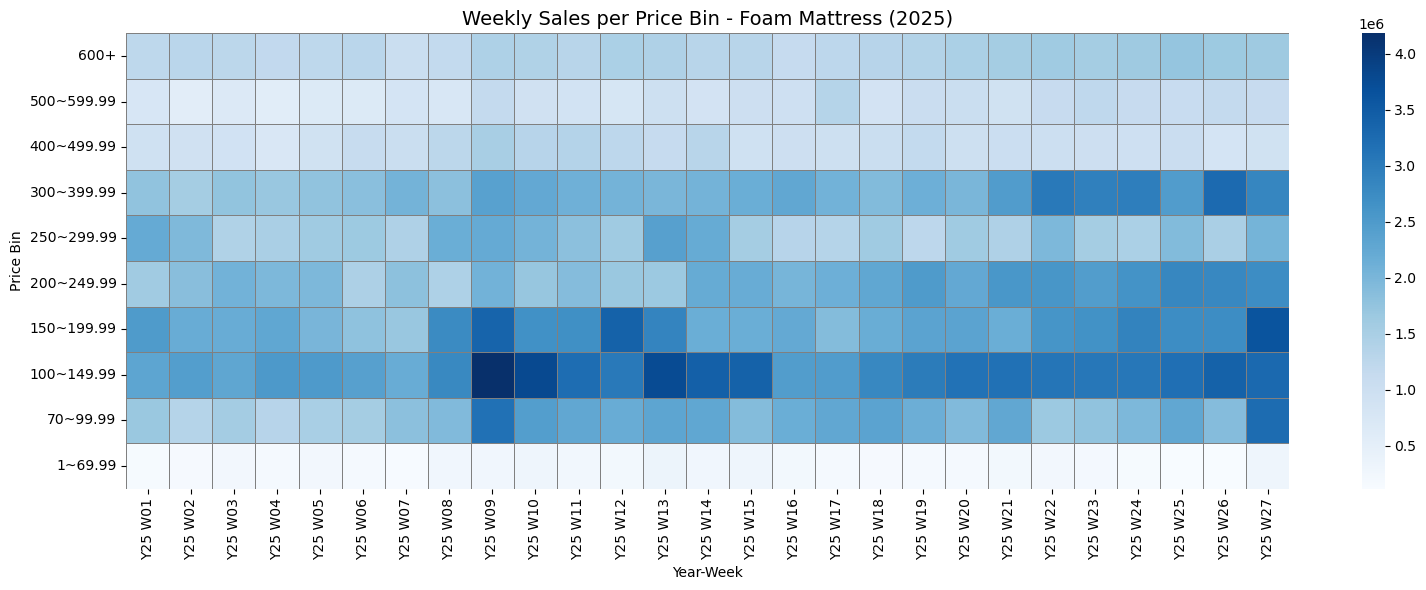

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\1939044259.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBin', 'yr_week'])['RetailSales']


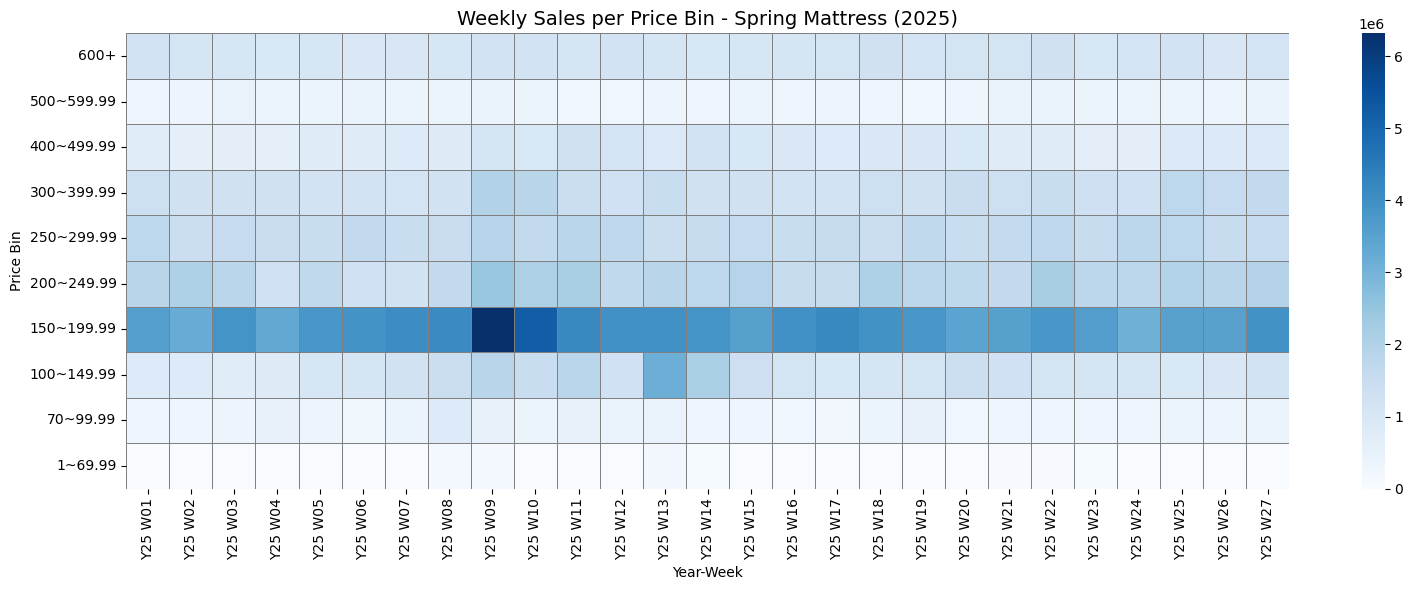

In [206]:
# Price Bin 설정
price_bins = [1, 70, 100, 150, 200, 250, 300, 400, 500, 600, np.inf]
bin_labels = [
    "1~69.99", "70~99.99", "100~149.99", "150~199.99",
    "200~249.99", "250~299.99", "300~399.99", "400~499.99",
    "500~599.99", "600+"
]

def draw_heatmap(df, category_name):
    df_cat = df[
        (df['category'] == category_name) & (df['year'] == 2025)
    ].copy()
    if len(df_cat) == 0:
        print(f"No data for {category_name}")
        return
    df_cat['PriceBin'] = pd.cut(
        df_cat['RetailPrice'],
        bins=price_bins,
        labels=bin_labels,
        right=False,
        include_lowest=True
    )
    all_weeks = sorted(df_cat['yr_week'].unique())
    heatmap_data = (
        df_cat.groupby(['PriceBin', 'yr_week'])['RetailSales']
        .sum()
        .unstack(fill_value=0)
        .reindex(index=bin_labels[::-1], columns=all_weeks, fill_value=0)
    )
    plt.figure(figsize=(16, 6))
    sns.heatmap(
        heatmap_data,
        cmap="Blues",
        linewidths=0.5,
        linecolor='gray'
    )
    plt.title(f"Weekly Sales per Price Bin - {category_name} (2025)", fontsize=14)
    plt.xlabel("Year-Week")
    plt.ylabel("Price Bin")
    plt.tight_layout()
    plt.show()

# Foam Mattress
draw_heatmap(df, 'Foam Mattress')

# Spring Mattress
draw_heatmap(df, 'Spring Mattress')

C:\Users\최태욱\AppData\Local\Temp\ipykernel_31916\2227028325.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby(['PriceBucket', 'yr_week'])['RetailSales']


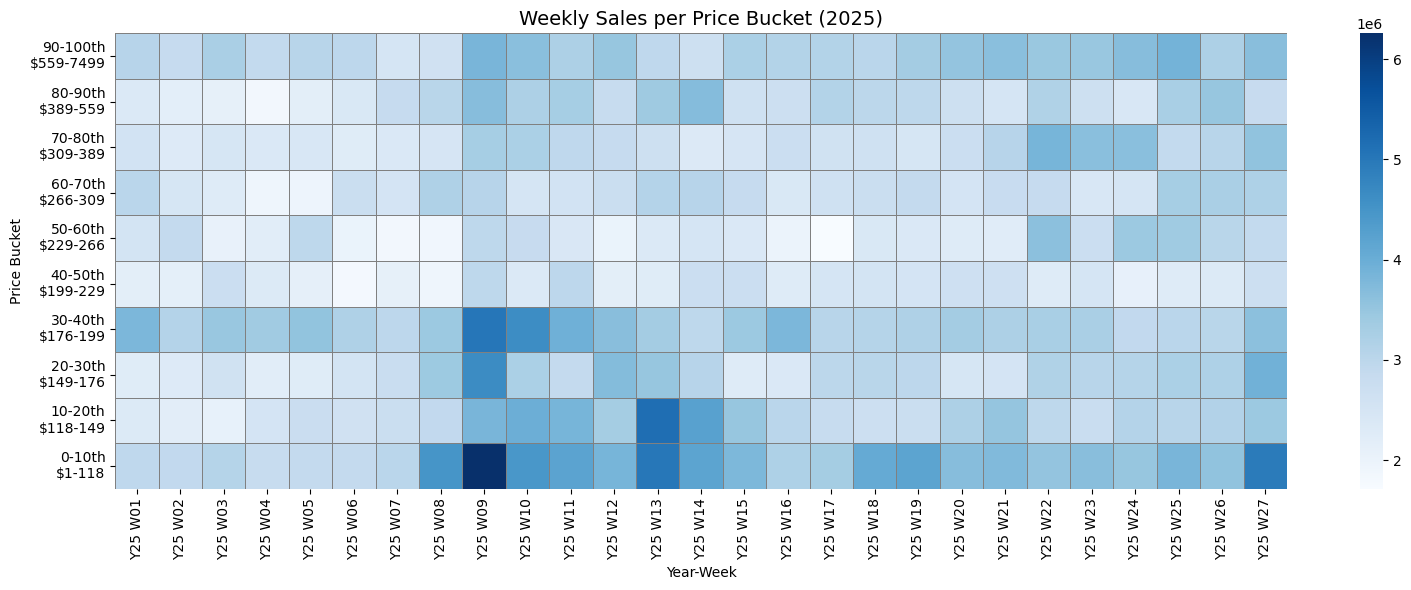

In [180]:

# 1. 2025년 + OTHERS 제외
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025) #&
    #(df['Brand_raw'] == 'ZINUS')
].copy()

# 2. 가격 퍼센타일 구간 계산 (2025년 전체 기준)
price_base = df_filtered['RetailPrice'].dropna()
percentiles = np.arange(0, 101, 10)
price_bins = np.percentile(price_base, q=percentiles)

bucket_labels = [
    f"{percentiles[i]}-{percentiles[i+1]}th\n${int(price_bins[i])}-{int(price_bins[i+1])}"
    for i in range(len(price_bins) - 1)
]

# 3. 가격 버킷 할당
df_filtered['PriceBucket'] = pd.cut(
    df_filtered['RetailPrice'],
    bins=price_bins,
    labels=bucket_labels,
    include_lowest=True
)

# ✅ Y축 가격대 내림차순 정렬
df_filtered['PriceBucket'] = pd.Categorical(
    df_filtered['PriceBucket'],
    categories=bucket_labels[::-1],
    ordered=True
)

# ✅ 4. 가격대 × 주차별 매출 집계
heatmap_data = (
    df_filtered.groupby(['PriceBucket', 'yr_week'])['RetailSales']
               .sum()
               .unstack(fill_value=0)
)

# ✅ 5. 히트맵 시각화
plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data,
    cmap="Blues",
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Weekly Sales per Price Bucket (2025)", fontsize=14)
plt.xlabel("Year-Week")
plt.ylabel("Price Bucket")
plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_24044\3585644296.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBucket', 'yr_week'])['UnitsSold']


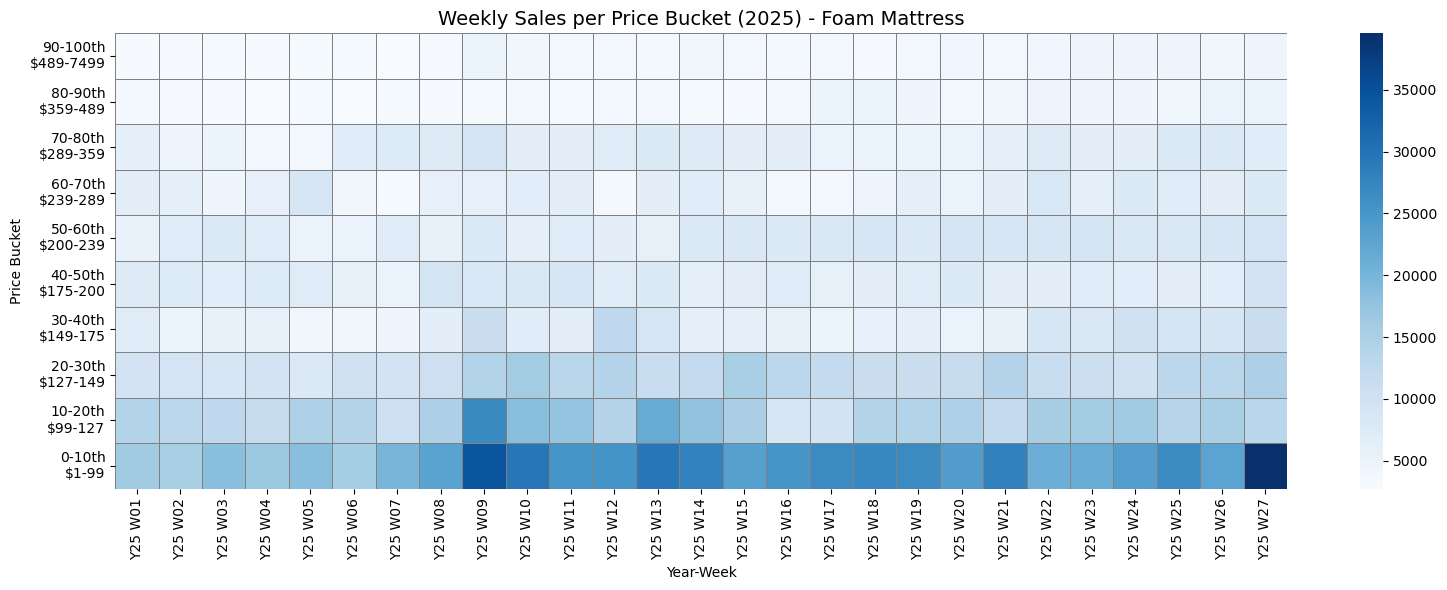

C:\Users\최태욱\AppData\Local\Temp\ipykernel_24044\3585644296.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cat.groupby(['PriceBucket', 'yr_week'])['UnitsSold']


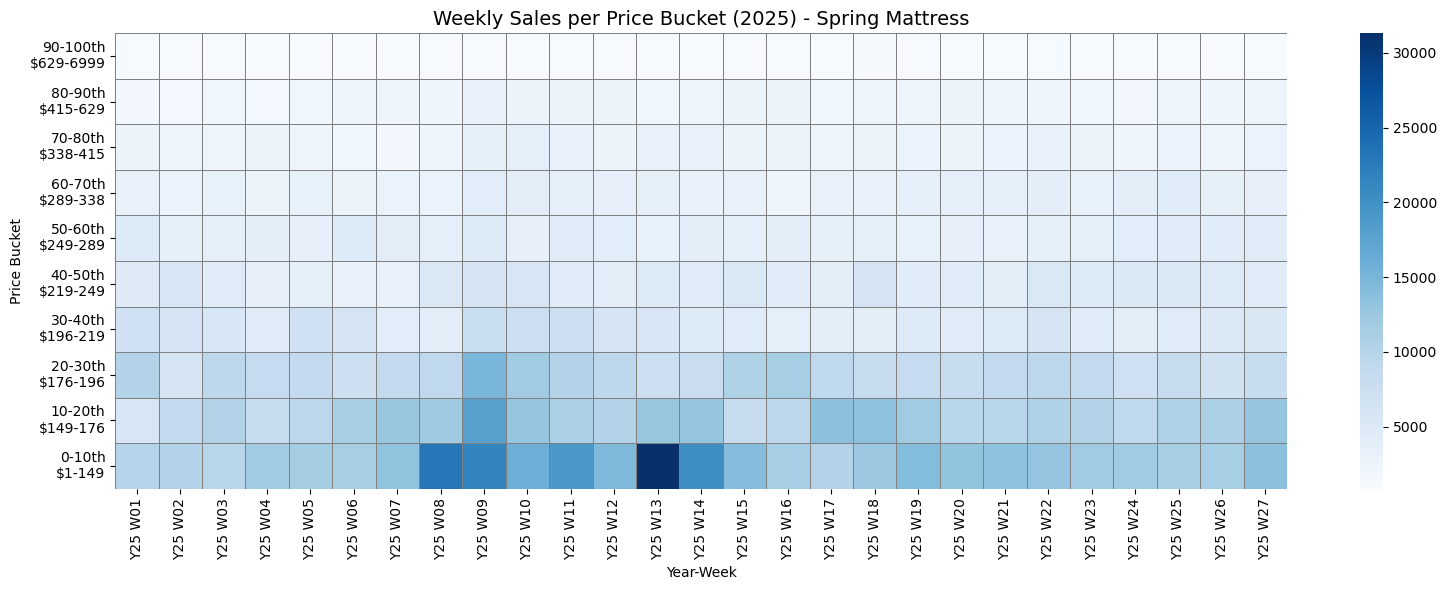

In [41]:

# 전처리: OTHERS 제외, 2025년만
df_filtered = df[
    (df['category'] != 'OTHERS') &
    (df['year'] == 2025)
].copy()

category_list = ['Foam Mattress', 'Spring Mattress']

for cat in category_list:
    df_cat = df_filtered[df_filtered['category'] == cat].copy()
    # 가격 퍼센타일 구간 (해당 카테고리에서만)
    price_base = df_cat['RetailPrice'].dropna()
    if len(price_base) < 2:
        print(f"{cat} 데이터가 충분하지 않습니다.")
        continue

    percentiles = np.arange(0, 101, 10)
    price_bins = np.percentile(price_base, q=percentiles)
    # 동일 가격 구간이 있으면 에러 발생 → 중복 제거
    price_bins = np.unique(price_bins)
    # 라벨 재생성 (bin 길이에 맞게)
    bucket_labels = [
        f"{i*10}-{(i+1)*10}th\n${int(price_bins[i])}-{int(price_bins[i+1])}"
        for i in range(len(price_bins) - 1)
    ]

    # 가격 버킷 할당
    df_cat['PriceBucket'] = pd.cut(
        df_cat['RetailPrice'],
        bins=price_bins,
        labels=bucket_labels,
        include_lowest=True
    )
    df_cat['PriceBucket'] = pd.Categorical(
        df_cat['PriceBucket'],
        categories=bucket_labels[::-1],
        ordered=True
    )

    # 히트맵용 데이터
    heatmap_data = (
        #df_cat.groupby(['PriceBucket', 'yr_week'])['RetailSales']
        df_cat.groupby(['PriceBucket', 'yr_week'])['UnitsSold']
              .sum()
              .unstack(fill_value=0)
    )

    plt.figure(figsize=(16, 6))
    sns.heatmap(
        heatmap_data,
        cmap="Blues",
        linewidths=0.5,
        linecolor='gray'
    )
    plt.title(f"Weekly Sales per Price Bucket (2025) - {cat}", fontsize=14)
    plt.xlabel("Year-Week")
    plt.ylabel("Price Bucket")
    plt.tight_layout()
    plt.show()

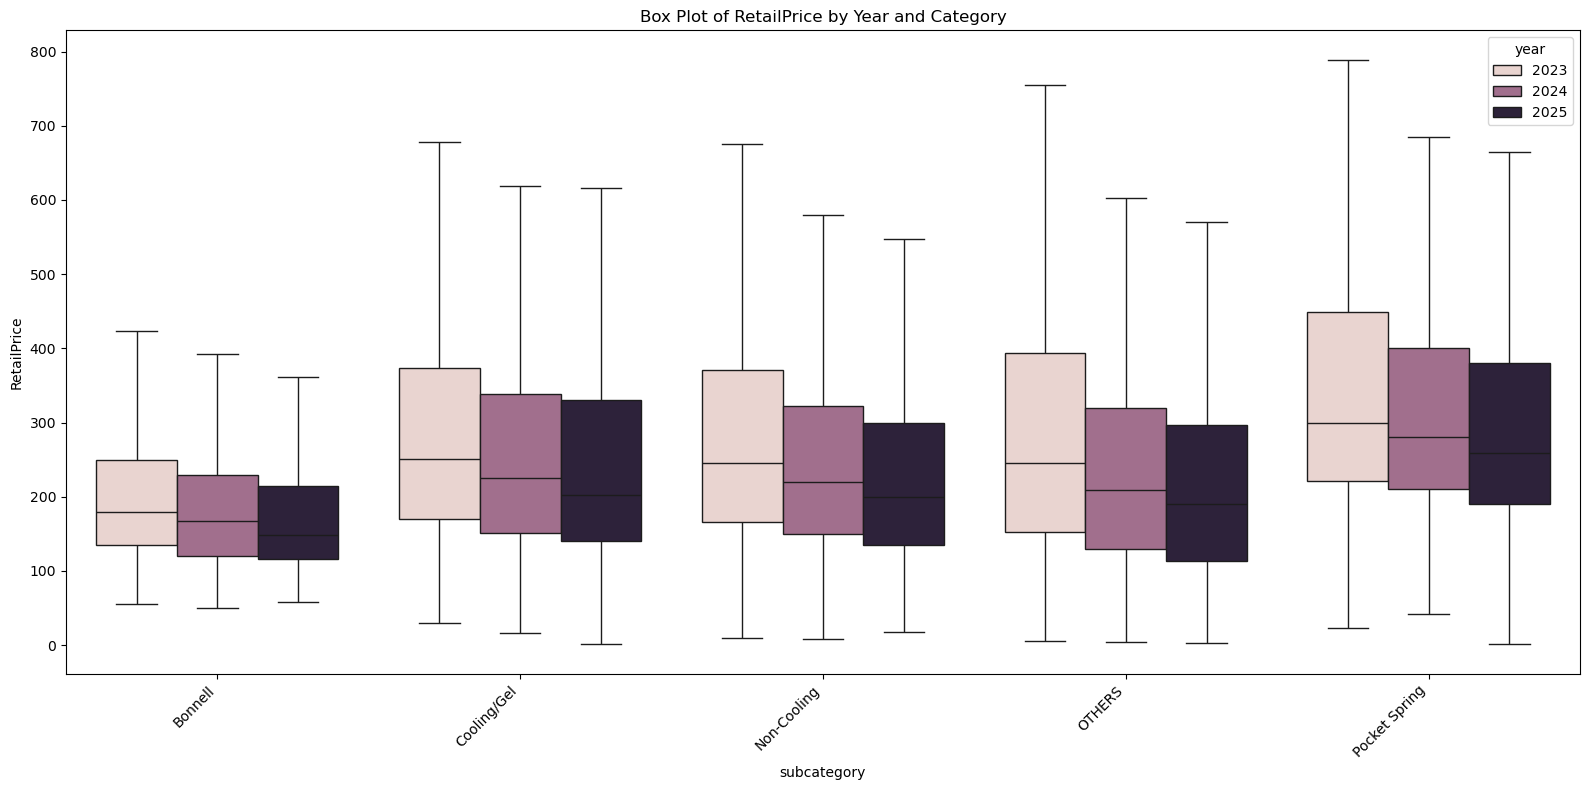

In [102]:

plt.figure(figsize=(16, 8))
sns.boxplot(
    data=df[df['RetailPrice'] > 0],  # 0 이하 제외 (로그변환 등에도 안전)
    x='subcategory',
    y='RetailPrice',
    hue='year',        # 분기로 색 구분
    showfliers=False         # 이상치 점 표시 안함 (원하면 True로)
)

plt.xticks(rotation=45, ha='right')
plt.title('Box Plot of RetailPrice by Year and Category')
plt.ylabel('RetailPrice')
plt.tight_layout()
plt.legend(title='year')
plt.show()

### 4. Market Share 분석

In [135]:
df1 = df.copy()

In [137]:
# 1. 2025년 데이터 필터링
df_2025 = df1[df1['year'] == 2025].copy()

# 2. Brand_raw별 매출 합계 집계
brand_sales_2025 = (
    df_2025.groupby('Brand_raw')['RetailSales']
           .sum()
           .reset_index()
           .sort_values(by='RetailSales', ascending=False)
)

# 3. CSV로 저장
brand_sales_2025.to_csv('brand_sales_2025_sorted.csv', index=False)

# (선택) 상위 5개 출력
print(brand_sales_2025.head())

    Brand_raw   RetailSales
610     ZINUS  1.401663e+08
386   NOVILLA  6.276125e+07
168       FDW  3.963378e+07
352     MLILY  3.545190e+07
375    NECTAR  3.312092e+07


In [166]:
print(brand_sales_2025['Brand_raw'].nunique())

619


In [141]:
# 1. 2025년 + Foam/Spring만 필터링
target_cats = ['Foam Mattress', 'Spring Mattress']
df_2025 = df1[(df1['year'] == 2025) & (df1['category'].isin(target_cats))].copy()

# 2. category, Brand_raw별 매출 합계 집계
brand_sales_by_cat = (
    df_2025.groupby(['category', 'Brand_raw'])['RetailSales']
           .sum()
           .reset_index()
)

# 3. category별 Top 10 브랜드 출력
topn = 10
for category, group in brand_sales_by_cat.groupby('category'):
    top_brands = group.sort_values(by='RetailSales', ascending=False).head(topn)
    print(f"\n[Category: {category}] Top {topn} Brands by RetailSales")
    print(top_brands[['Brand_raw', 'RetailSales']])


[Category: Foam Mattress] Top 10 Brands by RetailSales
               Brand_raw   RetailSales
297                ZINUS  1.143750e+08
192              NOVILLA  4.922243e+07
84                   FDW  3.957806e+07
172                MLILY  3.400318e+07
184               NECTAR  2.413848e+07
96                GAESTE  1.878955e+07
73               EGOHOME  1.292322e+07
50              COOL GEL  1.213054e+07
20   BEST PRICE MATTRESS  1.065620e+07
70               DYONERY  1.015861e+07

[Category: Spring Mattress] Top 10 Brands by RetailSales
                      Brand_raw  RetailSales
567                       ZINUS  25788347.47
321                    BEDSTORY  12725569.86
374                FP FLEXPEDIC  12281239.32
466                     NOVILLA  11658139.23
450                     MOLBIUS  11592986.92
551                   VESGANTTI  10312017.88
337                     COOLVIE  10161218.32
510  SIGNATURE DESIGN BY ASHLEY  10108251.09
408                     KOANTTI   7939715.86
462    

   yr_month  ZINUS_MarketShare(%)
0     23-01             21.630911
1     23-02             19.223365
2     23-03             21.851210
3     23-04             21.663981
4     23-05             17.962815
5     23-06             16.717315
6     23-07             19.217889
7     23-08             15.678568
8     23-09             14.528470
9     23-10             12.593751
10    23-11             12.986644
11    23-12             19.707853
12    24-01             16.110558
13    24-02             13.016853
14    24-03             15.205036
15    24-04             16.335339
16    24-05             14.540987
17    24-06             15.337745
18    24-07             14.346452
19    24-08             14.508770
20    24-09             16.601391
21    24-10             11.666375
22    24-11             12.799560
23    24-12             11.704315
24    25-01             14.275058
25    25-02             15.178152
26    25-03             16.301423
27    25-04             16.667450
28    25-05   

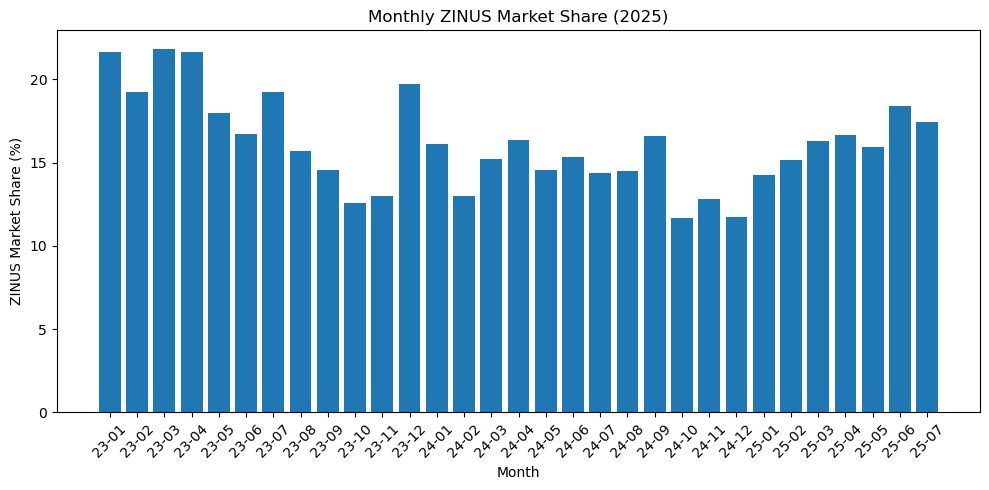

In [174]:
# 1. 2025년 데이터 필터링
#df_2025 = df1[df1['year'] == 2025].copy()

# 2. 월별 전체 매출 집계
monthly_total_sales = (
    df1.groupby('yr_month')['RetailSales']
           .sum()
           .reset_index()
           .rename(columns={'RetailSales': 'TotalSales'})
)

# 3. 월별 ZINUS 매출 집계
monthly_zinus_sales = (
    df1[df1['Brand_raw'].str.upper() == 'ZINUS']
    .groupby('yr_month')['RetailSales']
    .sum()
    .reset_index()
    .rename(columns={'RetailSales': 'ZinusSales'})
)

# 4. 월별 MarketShare(%) 계산
monthly_market = pd.merge(monthly_total_sales, monthly_zinus_sales, on='yr_month', how='left')
monthly_market['ZinusSales'] = monthly_market['ZinusSales'].fillna(0)
monthly_market['ZINUS_MarketShare(%)'] = (monthly_market['ZinusSales'] / monthly_market['TotalSales']) * 100

# 5. 결과 출력
print(monthly_market[['yr_month', 'ZINUS_MarketShare(%)']])

plt.figure(figsize=(10, 5))
plt.bar(monthly_market['yr_month'], monthly_market['ZINUS_MarketShare(%)'])
plt.xlabel('Month')
plt.ylabel('ZINUS Market Share (%)')
plt.title('Monthly ZINUS Market Share (2025)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


[Category: Foam Mattress]
   yr_month  ZINUS_MarketShare(%)
0     23-01             28.628112
1     23-02             24.429491
2     23-03             28.568155
3     23-04             29.006693
4     23-05             23.316958
5     23-06             21.830175
6     23-07             25.616652
7     23-08             22.191880
8     23-09             19.807475
9     23-10             17.742008
10    23-11             19.048443
11    23-12             29.181941
12    24-01             24.537245
13    24-02             20.329131
14    24-03             24.725006
15    24-04             25.570044
16    24-05             22.434140
17    24-06             25.081021
18    24-07             20.894985
19    24-08             23.932235
20    24-09             29.306924
21    24-10             19.112802
22    24-11             19.906940
23    24-12             17.494542
24    25-01             21.928375
25    25-02             23.787957
26    25-03             26.633516
27    25-04          

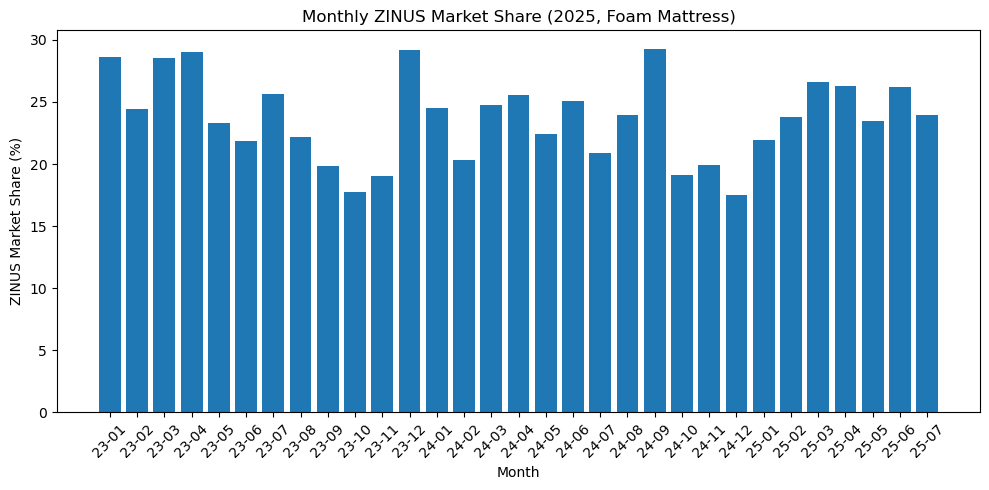


[Category: Spring Mattress]
   yr_month  ZINUS_MarketShare(%)
0     23-01             11.268434
1     23-02             12.879992
2     23-03             13.410256
3     23-04             11.429523
4     23-05             11.296230
5     23-06             10.354024
6     23-07             10.622993
7     23-08              8.035823
8     23-09              9.253170
9     23-10              7.116290
10    23-11              6.051045
11    23-12              9.108785
12    24-01              7.538744
13    24-02              6.787448
14    24-03              6.261483
15    24-04              6.900212
16    24-05              6.952270
17    24-06              7.033318
18    24-07              9.412910
19    24-08              6.780195
20    24-09              6.036159
21    24-10              5.382894
22    24-11              6.230600
23    24-12              5.948663
24    25-01              7.517555
25    25-02              7.524375
26    25-03              6.489518
27    25-04        

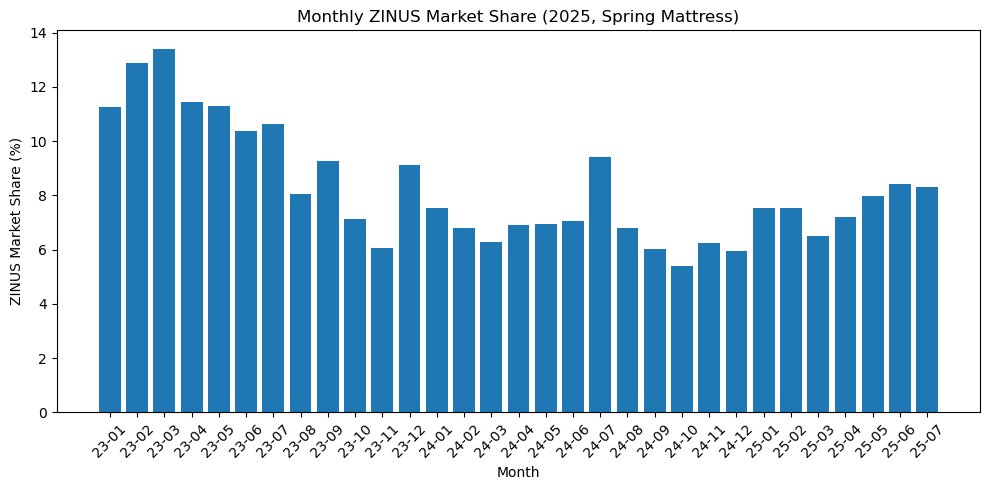

In [176]:
categories = ['Foam Mattress', 'Spring Mattress']

for cat in categories:
    # 1. 해당 카테고리만 필터링
    df_cat = df1[df1['category'] == cat].copy()
    
    # 2. 월별 전체 매출 집계
    monthly_total_sales = (
        df_cat.groupby('yr_month')['RetailSales']
              .sum()
              .reset_index()
              .rename(columns={'RetailSales': 'TotalSales'})
    )

    # 3. 월별 ZINUS 매출 집계
    monthly_zinus_sales = (
        df_cat[df_cat['Brand_raw'].str.upper() == 'ZINUS']
        .groupby('yr_month')['RetailSales']
        .sum()
        .reset_index()
        .rename(columns={'RetailSales': 'ZinusSales'})
    )

    # 4. 월별 MarketShare(%) 계산
    monthly_market = pd.merge(monthly_total_sales, monthly_zinus_sales, on='yr_month', how='left')
    monthly_market['ZinusSales'] = monthly_market['ZinusSales'].fillna(0)
    monthly_market['ZINUS_MarketShare(%)'] = (monthly_market['ZinusSales'] / monthly_market['TotalSales']) * 100

    # 5. 결과 출력 (옵션)
    print(f"\n[Category: {cat}]")
    print(monthly_market[['yr_month', 'ZINUS_MarketShare(%)']])

    # 6. 막대그래프
    plt.figure(figsize=(10, 5))
    plt.bar(monthly_market['yr_month'], monthly_market['ZINUS_MarketShare(%)'])
    plt.xlabel('Month')
    plt.ylabel('ZINUS Market Share (%)')
    plt.title(f'Monthly ZINUS Market Share (2025, {cat})')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

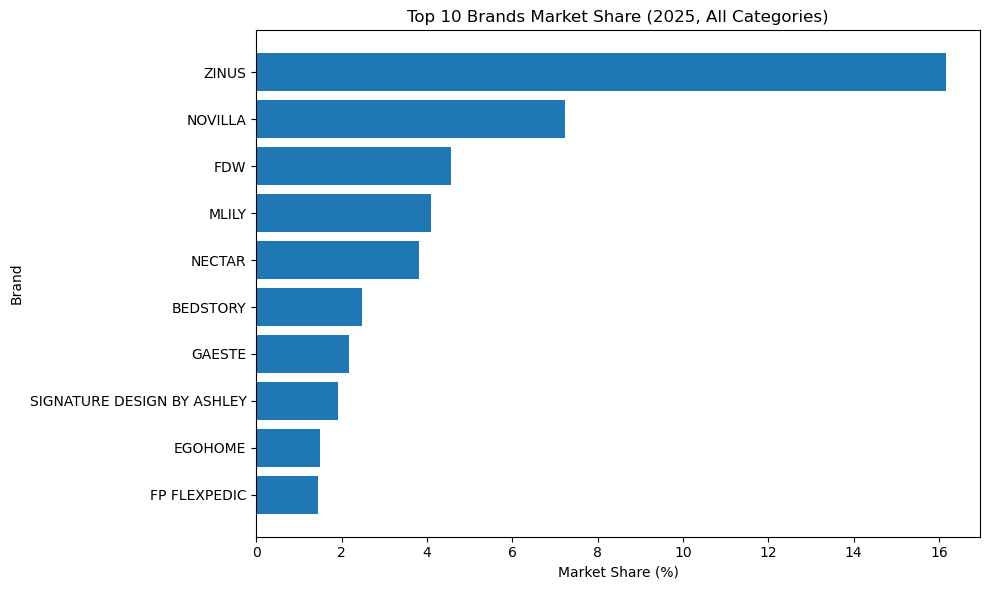

In [168]:
opn = 10

# 1. 2025년 전체 데이터만 사용 (category 구분 X)
df_2025_total = df1[df1['year'] == 2025]

# 2. 브랜드별 매출 집계
brand_sales_all = (
    df_2025_total.groupby('Brand_raw')['RetailSales']
                 .sum()
                 .reset_index()
                 .sort_values(by='RetailSales', ascending=False)
)

# 3. Top 10 브랜드 및 Others 계산
top_brands = brand_sales_all.head(topn).copy()
others_sales = brand_sales_all['RetailSales'][topn:].sum()

# 4. MarketShare 계산 (Top10 + Others 기준)
total_sales = top_brands['RetailSales'].sum() + others_sales
top_brands['MarketShare'] = top_brands['RetailSales'] / total_sales * 100

# 5. 그래프 (Top10만 표시)
plt.figure(figsize=(10, 6))
plt.barh(top_brands['Brand_raw'], top_brands['MarketShare'])
plt.xlabel('Market Share (%)')
plt.ylabel('Brand')
plt.title('Top 10 Brands Market Share (2025, All Categories)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

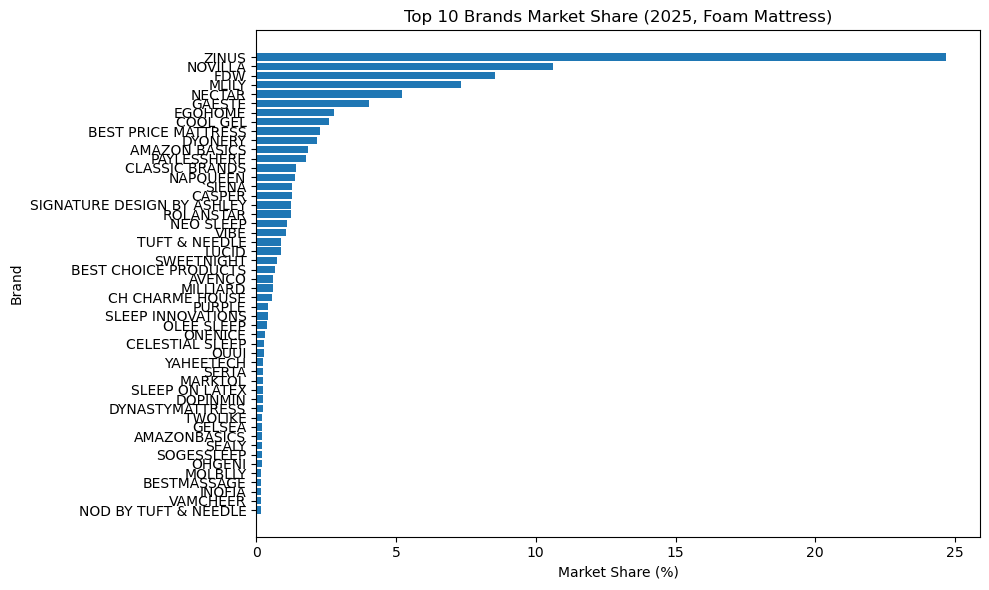

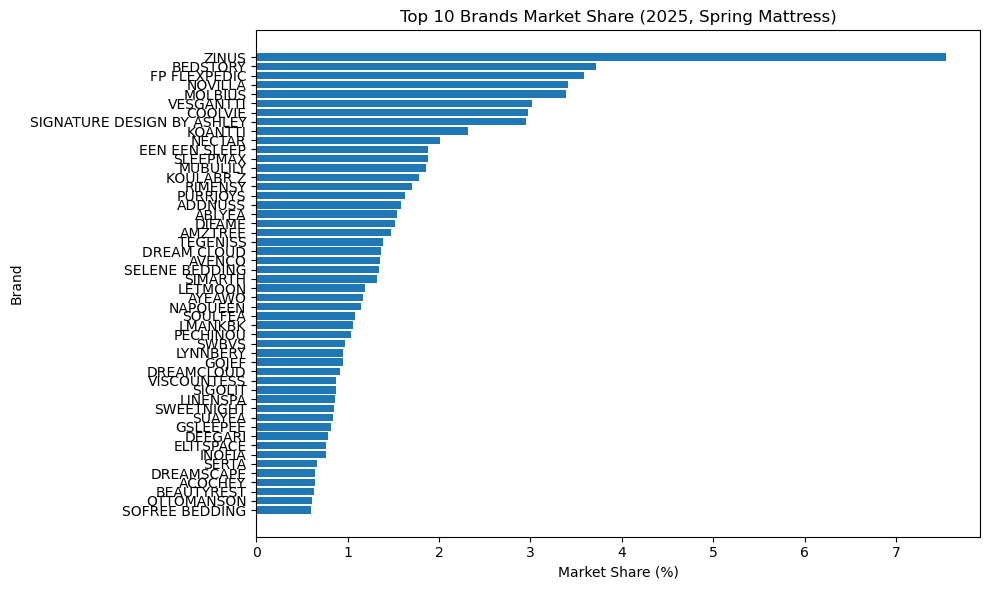

In [180]:
categories = ['Foam Mattress', 'Spring Mattress']
topn = 50

for cat in categories:
    df_2025_cat = df1[(df1['year'] == 2025) & (df1['category'] == cat)]
    
    # 전체 브랜드 매출 집계
    brand_sales_all = (
        df_2025_cat.groupby('Brand_raw')['RetailSales']
                   .sum()
                   .reset_index()
                   .sort_values(by='RetailSales', ascending=False)
    )
    
    # Top 10 추출 및 Others 계산
    top_brands = brand_sales_all.head(topn).copy()
    others_sales = brand_sales_all['RetailSales'][topn:].sum()
    
    # MarketShare 계산 (Top10 + Others 기준)
    total_sales = top_brands['RetailSales'].sum() + others_sales
    top_brands['MarketShare'] = top_brands['RetailSales'] / total_sales * 100
    
    # 그래프 (Top10만 표시)
    plt.figure(figsize=(10, 6))
    plt.barh(top_brands['Brand_raw'], top_brands['MarketShare'])
    plt.xlabel('Market Share (%)')
    plt.ylabel('Brand')
    plt.title(f'Top 10 Brands Market Share (2025, {cat})')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

   yr_month  ZINUS_MarketShare(%)
0     23-01              9.447689
1     23-02              9.851803
2     23-03              9.348261
3     23-04             10.021913
4     23-05             10.159380
5     23-06              7.334778
6     23-07              7.393668
7     23-08              6.271916
8     23-09              6.256496
9     23-10              5.410728
10    23-11              4.626941
11    23-12              6.696563
12    24-01              5.776762
13    24-02              5.017301
14    24-03              4.896707
15    24-04              4.752167
16    24-05              4.997880
17    24-06              5.321370
18    24-07              6.943784
19    24-08              4.201077
20    24-09              3.416354
21    24-10              3.776430
22    24-11              4.152049
23    24-12              2.931926
24    25-01              3.218521
25    25-02              3.123281
26    25-03              2.972973
27    25-04              4.174873
28    25-05   

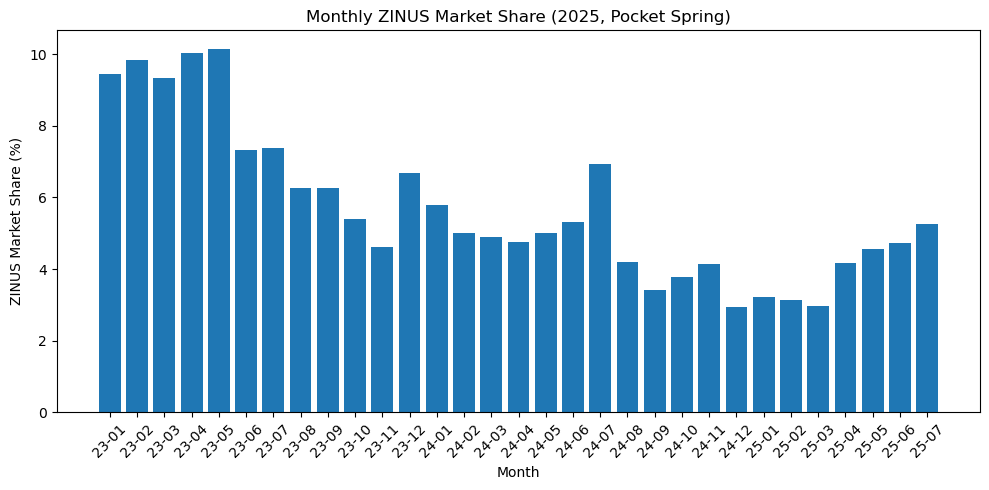

In [183]:

# 1. pocket spring만 필터링
df_pocket = df1[(df1['category'] == 'Spring Mattress') & (df1['subcategory'] == 'Pocket Spring')]

# 2. 월별 전체 매출 집계
monthly_total_sales = (
    df_pocket.groupby('yr_month')['RetailSales']
             .sum()
             .reset_index()
             .rename(columns={'RetailSales': 'TotalSales'})
)

# 3. 월별 ZINUS 매출 집계
monthly_zinus_sales = (
    df_pocket[df_pocket['Brand_raw'].str.upper() == 'ZINUS']
    .groupby('yr_month')['RetailSales']
    .sum()
    .reset_index()
    .rename(columns={'RetailSales': 'ZinusSales'})
)

# 4. 월별 MarketShare(%) 계산
monthly_market = pd.merge(monthly_total_sales, monthly_zinus_sales, on='yr_month', how='left')
monthly_market['ZinusSales'] = monthly_market['ZinusSales'].fillna(0)
monthly_market['ZINUS_MarketShare(%)'] = (monthly_market['ZinusSales'] / monthly_market['TotalSales']) * 100

# 5. 결과 출력 (옵션)
print(monthly_market[['yr_month', 'ZINUS_MarketShare(%)']])

# 6. 막대그래프
plt.figure(figsize=(10, 5))
plt.bar(monthly_market['yr_month'], monthly_market['ZINUS_MarketShare(%)'])
plt.xlabel('Month')
plt.ylabel('ZINUS Market Share (%)')
plt.title('Monthly ZINUS Market Share (2025, Pocket Spring)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

                      Brand_raw  RetailSales  MarketShare(%)
21                     BEDSTORY  12725569.86        4.017779
73                 FP FLEXPEDIC  12281239.32        3.877493
260                       ZINUS  12140687.16        3.833117
146                     MOLBIUS  11592986.92        3.660194
161                     NOVILLA  11091284.60        3.501795
244                   VESGANTTI  10312017.88        3.255761
36                      COOLVIE  10161218.32        3.208149
204  SIGNATURE DESIGN BY ASHLEY   9995142.88        3.155715
106                     KOANTTI   7939715.86        2.506766
157                      NECTAR   6872422.27        2.169795
58                EEN EEN SLEEP   6433890.91        2.031339
211                    SLEEPMAX   6427611.60        2.029357
150                    MUBULILY   6368115.20        2.010572
108                   KOULABR Z   6104652.07        1.927391
188                     RIMENSY   5842663.43        1.844674
184                    P

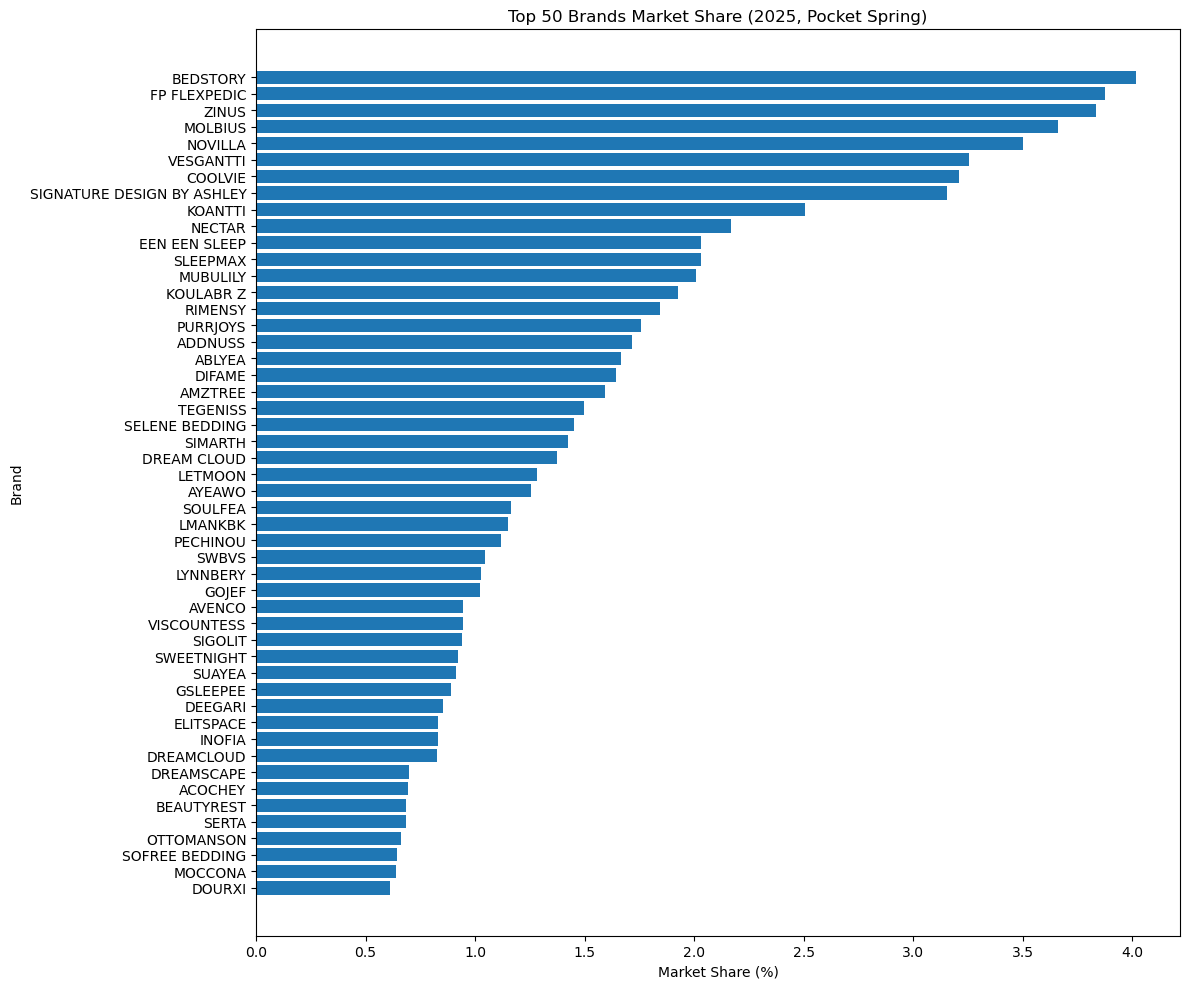

In [185]:
# 1. pocket spring 필터링 (2025년, Spring Mattress, pocket spring)
df_pocket = df1[
    (df1['year'] == 2025) &
    (df1['category'] == 'Spring Mattress') &
    (df1['subcategory'].str.lower() == 'pocket spring')
]

# 2. 브랜드별 매출 합계 집계 (내림차순 정렬)
brand_sales = (
    df_pocket.groupby('Brand_raw')['RetailSales']
             .sum()
             .reset_index()
             .sort_values(by='RetailSales', ascending=False)
)

# 3. Top 50 추출
topn = 50
top_brands = brand_sales.head(topn).copy()

# 4. 전체 매출 합계
total_sales = brand_sales['RetailSales'].sum()

# 5. 시장점유율(%) 계산
top_brands['MarketShare(%)'] = top_brands['RetailSales'] / total_sales * 100

# 6. 결과 확인
print(top_brands[['Brand_raw', 'RetailSales', 'MarketShare(%)']])

# (선택) 그래프
plt.figure(figsize=(12, 10))
plt.barh(top_brands['Brand_raw'], top_brands['MarketShare(%)'])
plt.xlabel('Market Share (%)')
plt.ylabel('Brand')
plt.title('Top 50 Brands Market Share (2025, Pocket Spring)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
topn = 10

for category, group in brand_sales_by_cat.groupby('category'):
    # 1. 매출 기준 정렬
    group_sorted = group.sort_values(by='RetailSales', ascending=False).reset_index(drop=True)
    # 2. Top N 브랜드
    top_brands = group_sorted.head(topn)
    # 3. Others 계산
    others = group_sorted.iloc[topn:]
    others_sales = others['RetailSales'].sum()
    # 4. Top N + Others 데이터프레임 생성
    result = top_brands[['Brand_raw', 'RetailSales']].copy()
    if others_sales > 0:
        others_row = pd.DataFrame({
            'Brand_raw': ['Others'],
            'RetailSales': [others_sales]
        })
        result = pd.concat([result, others_row], ignore_index=True)
    # 5. 비율 컬럼 추가
    total_sales = result['RetailSales'].sum()
    result['SalesRatio'] = (result['RetailSales'] / total_sales * 100).round(2)
    # 6. 출력
    print(f"\n[Category: {category}] Top {topn} Brands (+Others) by RetailSales")
    print(result)

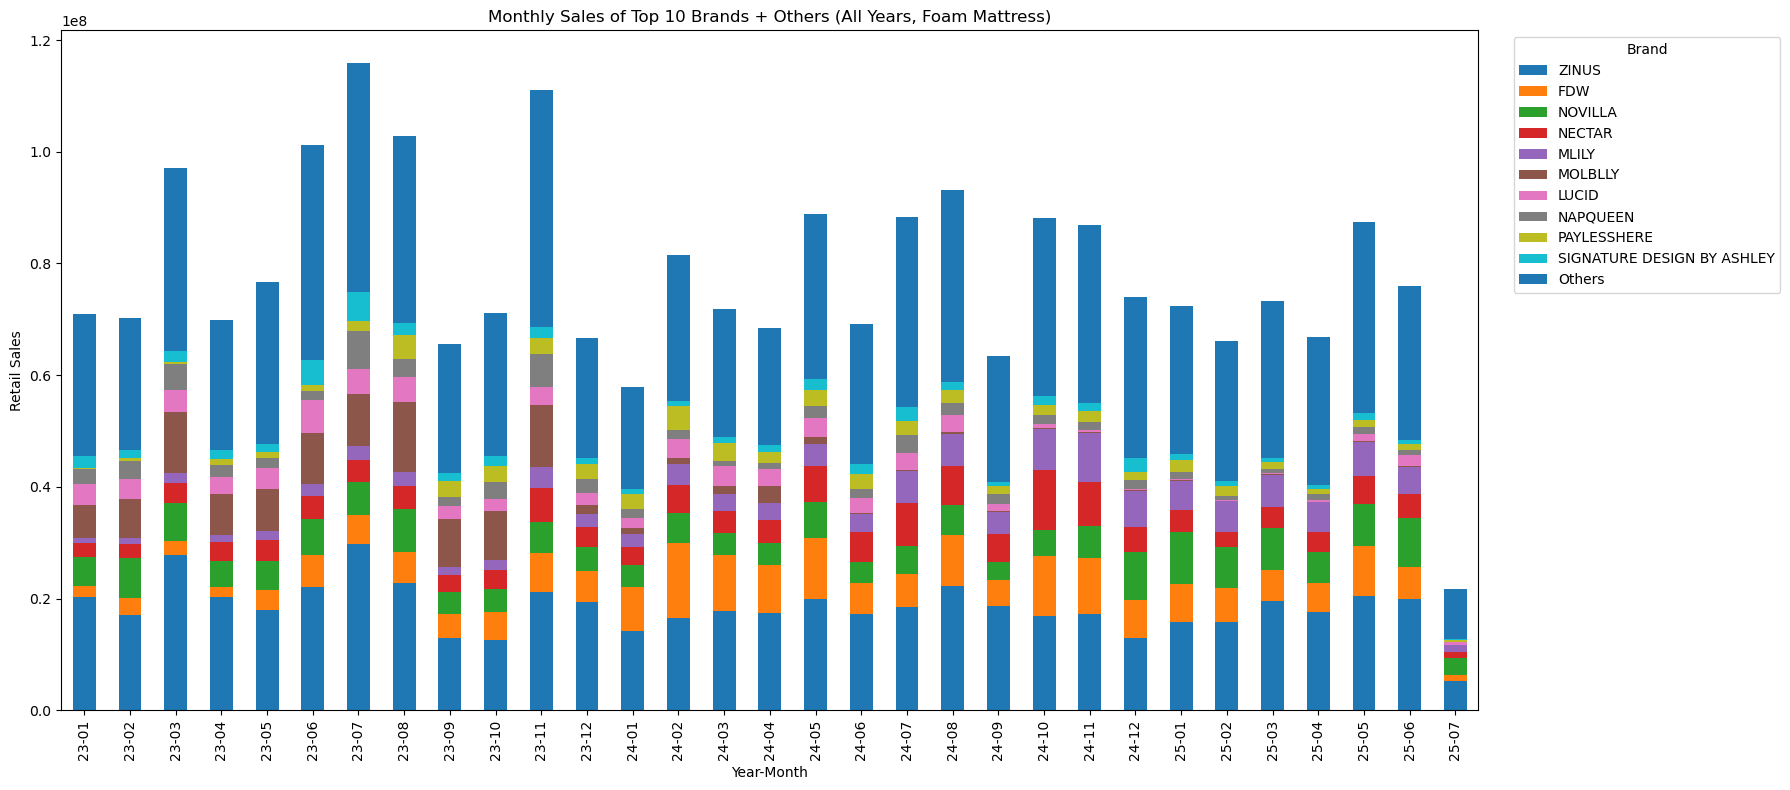

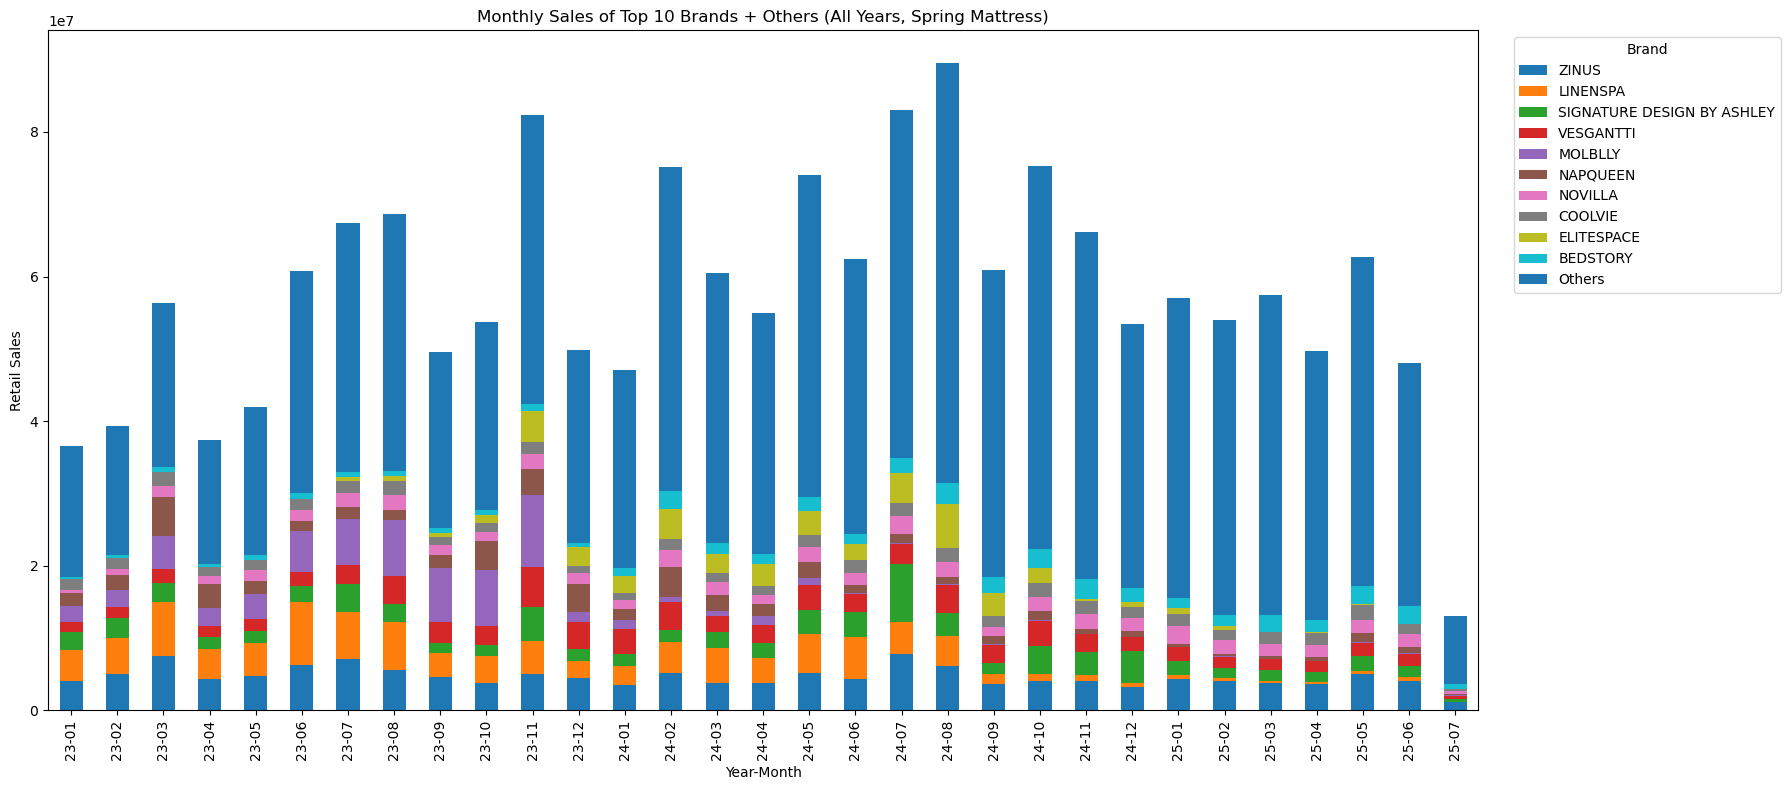

In [157]:
target_cats = ['Foam Mattress', 'Spring Mattress']

for cat in target_cats:
    # 1. 카테고리별 전체 데이터 추출
    df_cat = df1[df1['category'] == cat].copy()
    if df_cat.empty:
        continue

    # 2. 연/월, 브랜드별 매출 집계 (yr_month 사용)
    monthly_brand_sales = (
        df_cat.groupby(['yr_month', 'Brand_raw'])['RetailSales']
              .sum()
              .reset_index()
    )

    # 3. 전체 기간 Top 10 브랜드 선정
    top_brands = (
        monthly_brand_sales.groupby('Brand_raw')['RetailSales']
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .index
    )

    # 4. Others 처리
    monthly_brand_sales['Brand_Plot'] = monthly_brand_sales['Brand_raw'].where(
        monthly_brand_sales['Brand_raw'].isin(top_brands), 'Others'
    )

    # 5. Others 포함 월별 합계 재집계
    monthly_plot = (
        monthly_brand_sales.groupby(['yr_month', 'Brand_Plot'])['RetailSales']
        .sum()
        .reset_index()
    )

    # 6. Pivot (Top 10 + Others)
    plot_brands = list(top_brands) + ['Others']
    pivot = monthly_plot.pivot(index='yr_month', columns='Brand_Plot', values='RetailSales').fillna(0)
    pivot = pivot[[b for b in plot_brands if b in pivot.columns]]

    # 7. 누적 막대그래프 그리기
    plt.figure(figsize=(18, 8))
    pivot.plot(kind='bar', stacked=True, ax=plt.gca())
    plt.title(f'Monthly Sales of Top 10 Brands + Others (All Years, {cat})')
    plt.xlabel('Year-Month')
    plt.ylabel('Retail Sales')
    plt.legend(title='Brand', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

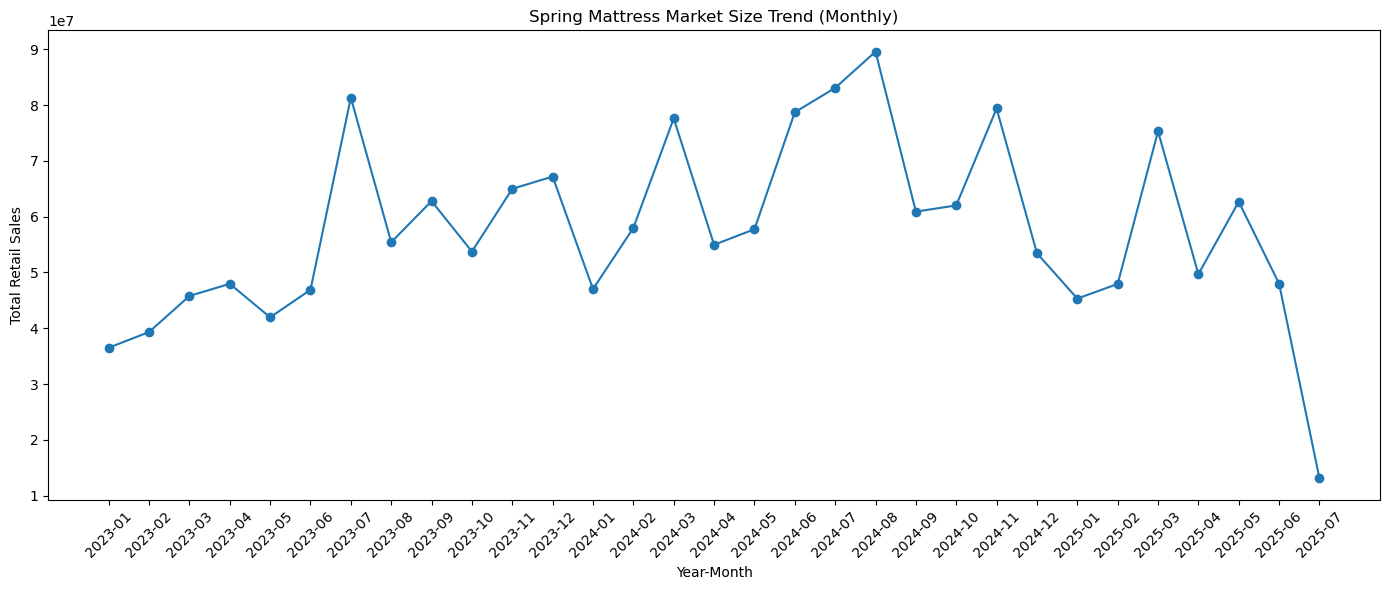

In [153]:

# 1. Spring Mattress 데이터만 추출
df_spring = df1[df1['category'] == 'Spring Mattress'].copy()

# 2. 연/월 추출 (WeekEnding 기준)
df_spring['YearMonth'] = pd.to_datetime(df_spring['WeekEnding']).dt.to_period('M')

# 3. 연/월별 매출 합계 집계
monthly_market = (
    df_spring.groupby('YearMonth')['RetailSales']
    .sum()
    .reset_index()
)

# 4. 라인그래프로 시장 크기 추이 시각화
plt.figure(figsize=(14, 6))
plt.plot(monthly_market['YearMonth'].astype(str), monthly_market['RetailSales'], marker='o')
plt.title('Spring Mattress Market Size Trend (Monthly)')
plt.xlabel('Year-Month')
plt.ylabel('Total Retail Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()